# Prompt Engineering

> **De prompts básicos a técnicas avanzadas con evaluación y benchmarking real**

---
# 1. ¿Qué es el Prompt Engineering?

El **Prompt Engineering** es el arte y la ciencia de diseñar instrucciones (prompts) que guían a los modelos de lenguaje (LLMs) para producir outputs precisos, relevantes y consistentes.

> un buen prompt puede marcar la diferencia entre un output inútil y uno que resuelve el problema a la primera.

## ¿Por qué importa?

| Sin PE | Con PE |
|---|---|
| Respuestas genéricas | Respuestas específicas y accionables |
| Alta varianza entre ejecuciones | Outputs reproducibles |
| Alucinaciones frecuentes | Menos errores y fabricaciones |
| Formato inconsistente | Estructura predecible |
| Muchos tokens desperdiciados | Eficiencia y menor costo |

## El espacio del prompt

Un prompt puede contener cualquier combinación de:
- **Instrucción** — qué debe hacer el modelo
- **Contexto** — información de fondo
- **Datos de entrada** — el material a procesar
- **Ejemplos** — few-shots que muestran el formato esperado
- **Formato de salida** — cómo debe estructurarse la respuesta
- **Restricciones** — qué evitar o no hacer
- **Rol** — qué personaje debe adoptar el modelo

## Taxonomía de técnicas

```
Prompt Engineering
├── Básicas
│   ├── Zero-Shot
│   ├── Few-Shot
│   ├── Example-Weighting
│   ├── Negative Prompting
│   └── Template / Placeholders
├── Rol y Persona
│   ├── Role Prompting
│   ├── Persona Prompting
│   └── Devil's Advocate
├── Razonamiento
│   ├── Chain-of-Thought (CoT)
│   ├── AutoCoT
│   ├── Chain-of-Symbols (CoS)
│   ├── Self-Consistency
│   ├── Tree-of-Thought (ToT)
│   ├── Graph-of-Thought (GoT)
│   ├── Thread-of-Thought (ThT)
│   ├── Self-Ask Prompting
│   └── Chain-of-Table Prompting (CTP)
├── Reducción de alucinaciones
│   ├── ReAct
│   ├── Chain-of-Verification (CoVe)
│   ├── Chain-of-Note (CoN)
│   └── Chain-of-Knowledge (CoK)
├── Interacción con el usuario
│   ├── Active Prompting
│   └── Rephrase and Respond (RaR)
├── Reflexión y metacognición
│   └── Stepback Prompting
├── Tono y emoción
│   └── Emotional Prompting
├── Prompt Tuning
│   └── Automatic Prompt Engineer (APE)
├── Generación de código
│   ├── Program-of-Thought (PoT)
│   └── Chain-of-Code (CoC)
├── Avanzadas / Composición
│   ├── Prompt Chaining
│   └── Meta-Prompting
└── Producción
    ├── Structured Outputs
    ├── Templates
    └── Evaluación / Benchmarking
```

In [15]:
# ============================================================
#  SETUP — Instalación y cliente
# ============================================================

# !pip install openai -q

import os
import json
import time
import re
import statistics
from typing import Optional
from openai import OpenAI

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- Configura tu API Key de OpenAI ---
# Si usas Colab, puedes guardarla de forma segura en 'Secrets' (icono de llave)
# y luego cargarla así:
from google.colab import userdata

openai_api_key = userdata.get('OPENAI_API_KEY')

# Si no está en Colab Secrets, intenta obtenerla de una variable de entorno local.
if not openai_api_key:
    openai_api_key = os.environ.get('OPENAI_API_KEY')

# Si todavía no se encuentra la clave, lanza un error.
if not openai_api_key:
    print("⚠️  ADVERTENCIA: La variable de entorno 'OPENAI_API_KEY' no está configurada.")
    print("Por favor, configúrala en Colab Secrets o como variable de entorno.")
    raise ValueError("OPENAI_API_KEY no configurada. No se puede inicializar el cliente OpenAI.")

client = OpenAI(api_key=openai_api_key)

# ── Estilo visual ─────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#e6edf3',       'grid.color': '#21262d',
    'grid.alpha': 0.5,             'font.size': 11,
    'axes.titlesize': 13,          'axes.titleweight': 'bold',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})
PALETTE = ['#58a6ff','#ff7b72','#3fb950','#d2a8ff',
           '#ffa657','#79c0ff','#f85149','#56d364']

# ── Helper de llamada central ────────────────────────────
def llm(prompt: str,
        system: str = 'Eres un asistente experto y conciso.',
        model: str = 'gpt-4o-mini', # Cambiado de gpt-4.1-mini a gpt-4o-mini
        temp: float = 0.7,
        max_tok: int = 600) -> str:
    """Llamada simplificada a la API."""
    r = client.chat.completions.create(
        model=model,
        messages=[
            {'role': 'system', 'content': system},
            {'role': 'user',   'content': prompt}
        ],
        temperature=temp,
        max_tokens=max_tok
    )
    return r.choices[0].message.content.strip()


def show(titulo: str, resultado: str, ancho: int = 70):
    """Imprime resultado con separadores."""
    print(f'\n{"─"*ancho}')
    print(f'  {titulo}')
    print(f'{"─"*ancho}')
    print(resultado)


print('✅ Setup completado')


✅ Setup completado


---
# 2. Anatomía de un Buen Prompt

Cada elemento del prompt activa distintos patrones en el modelo. Entender cómo interactúan es la base del prompt engineering.

In [17]:
# ============================================================
#  ANATOMÍA — Construir un prompt por partes
# ============================================================

# ── Prompt sin estructura (baseline malo) ─────────────────
prompt_malo = 'dime algo sobre machine learning'

# ── Prompt bien construido (mismo objetivo) ────────────────
prompt_bueno = """
## Rol
Eres un instructor senior de ciencia de datos con 10 años de experiencia
formando a ingenieros de software.

## Tarea
Escribe una definición de Machine Learning para un ingeniero de software
con experiencia en programación pero sin conocimientos previos de IA.

## Restricciones
- Máximo 120 palabras
- Sin jerga matemática compleja
- Incluye una analogía con programación tradicional
- Termina con 1 caso de uso concreto

## Formato de salida
Párrafo único sin listas ni bullet points.
"""

good_response = llm(prompt_malo)
bad_response = llm(prompt_bueno)

show('❌ PROMPT VAGO', bad_response)
show('✅ PROMPT BIEN ESTRUCTURADO', good_response)

print(f'\n📊 Longitudes:')
print(f'Prompt malo  → {len(prompt_malo)} chars  →  respuesta {len(bad_response)} chars')
print(f'Prompt bueno → {len(prompt_bueno)} chars  →  respuesta {len(good_response)} chars')


──────────────────────────────────────────────────────────────────────
  ❌ PROMPT VAGO
──────────────────────────────────────────────────────────────────────
Machine Learning es una rama de la inteligencia artificial que permite a las computadoras aprender de datos y mejorar su rendimiento en tareas específicas sin ser programadas explícitamente para ello. Es similar a cómo un ingeniero de software puede escribir un código que se ajusta a diferentes casos de uso, pero en lugar de seguir instrucciones fijas, el sistema identifica patrones y toma decisiones basadas en ejemplos previos. Por ejemplo, en el desarrollo de aplicaciones de reconocimiento de imágenes, un modelo de Machine Learning puede aprender a identificar objetos en fotos tras ser alimentado con miles de imágenes etiquetadas, mejorando su precisión con cada iteración.

──────────────────────────────────────────────────────────────────────
  ✅ PROMPT BIEN ESTRUCTURADO
────────────────────────────────────────────────────────

In [11]:
# ── Los 7 elementos de un prompt y su impacto ─────────────

elementos = {
    'Solo instrucción':        'Resume este texto: {{texto}}',

    '+ Contexto':              'Eres un periodista de tecnología. '
                               'Resume este texto: {{texto}}',

    '+ Audiencia':             'Eres un periodista de tecnología. '
                               'Resume este texto para ejecutivos no técnicos: {{texto}}',

    '+ Formato':               'Eres un periodista de tecnología. '
                               'Resume en 3 bullet points para ejecutivos no técnicos: {{texto}}',

    '+ Tono':                  'Eres un periodista de tecnología con tono optimista y divulgativo. '
                               'Resume en 3 bullet points para ejecutivos no técnicos. '
                               'Texto: {{texto}}',

    '+ Restricción':           'Eres un periodista de tecnología con tono optimista y divulgativo. '
                               'Resume en exactamente 3 bullet points (máx. 15 palabras cada uno) '
                               'para ejecutivos no técnicos. Sin jerga técnica. '
                               'Texto: {{texto}}',

    '+ Ejemplo de salida':     'Eres un periodista de tecnología. '
                               'Resume en 3 bullet points para ejecutivos. Sin jerga técnica.\n'
                               'Ejemplo: "• La IA reduce costos operativos en un 30%."\n'
                               'Texto: {{texto}}',
}

texto_muestra = (
    'Los transformers, introducidos en 2017, usan mecanismos de auto-atención '
    'que permiten procesar secuencias en paralelo, superando las limitaciones '
    'de las redes recurrentes. Han revolucionado el NLP y son la base de GPT, '
    'BERT y la mayoría de modelos modernos.'
)

print('Comparando el efecto de añadir elementos al prompt:\n')

resultados_elem = {}
for nombre, template in list(elementos.items())[:4]:   # Mostramos 4 para no usar demasiados tokens
    prompt = template.replace('{{texto}}', texto_muestra)
    resp = llm(prompt, system='Sigue las instrucciones exactamente.', temp=0.3)
    resultados_elem[nombre] = resp
    print(f'🔹 {nombre}:')
    print(f'{resp[:200]}')
    print()

Comparando el efecto de añadir elementos al prompt:

🔹 Solo instrucción:
   Los transformers, introducidos en 2017, utilizan mecanismos de auto-atención para procesar secuencias en paralelo, superando las limitaciones de las redes recurrentes. Han transformado el procesamient

🔹 + Contexto:
   Los transformers, presentados en 2017, utilizan mecanismos de auto-atención para procesar secuencias en paralelo, lo que supera las limitaciones de las redes recurrentes. Han transformado el procesami

🔹 + Audiencia:
   Los transformers, presentados en 2017, han transformado el procesamiento del lenguaje natural al permitir el análisis de datos en paralelo, lo que supera las limitaciones de las tecnologías anteriores

🔹 + Formato:
   - **Innovación en procesamiento de datos**: Los transformers utilizan mecanismos de auto-atención que permiten procesar secuencias de datos en paralelo, lo que mejora significativamente la eficiencia 



---
# 3. Zero-Shot Prompting

El modelo realiza la tarea **sin ejemplos previos**. Funciona bien en tareas que el modelo ya conoce bien de su entrenamiento. Es la forma más directa de prompting.

In [18]:
# ============================================================
#  ZERO-SHOT PROMPTING
# ============================================================

tareas_zero_shot = [
    {
        'nombre': 'Clasificación de sentimiento',
        'prompt': 'Clasifica el sentimiento de la siguiente reseña.\n'
                  'Responde SOLO con: POSITIVO, NEGATIVO o NEUTRO.\n\n'
                  'Reseña: "El hotel era aceptable. La habitación estaba limpia '
                  'pero el servicio de habitaciones tardó 45 minutos."'
    },
    {
        'nombre': 'Extracción de entidades',
        'prompt': 'Extrae todas las entidades nombradas del siguiente texto. '
                  'Clasifícalas en PERSONA, ORGANIZACIÓN, LUGAR o FECHA.\n'
                  'Responde en formato JSON.\n\n'
                  'Texto: "Elon Musk fundó SpaceX en 2002 en Hawthorne, California, '
                  'tras vender PayPal a eBay."'
    },
    {
        'nombre': 'Traducción con estilo',
        'prompt': 'Traduce al inglés formal (registro académico) el siguiente texto en español:\n\n'
                  '"La inteligencia artificial está cambiando el mundo a una velocidad '
                  'que nadie esperaba. Hay que adaptarse o quedarse atrás."'
    },
    {
        'nombre': 'Detección de código incorrecto',
        'prompt': 'Identifica el bug en este código Python y explica por qué falla.\n\n'
                  'def promedio(lista):\n'
                  '    total = 0\n'
                  '    for n in lista:\n'
                  '        total =+ n\n'
                  '    return total / len(lista)'
    },
]

for tarea in tareas_zero_shot:
    resultado = llm(tarea['prompt'], system='Eres un asistente preciso. Sigue las instrucciones al pie de la letra.', temp=0.1)
    show(f'Zero-Shot: {tarea["nombre"]}', resultado)


──────────────────────────────────────────────────────────────────────
  Zero-Shot: Clasificación de sentimiento
──────────────────────────────────────────────────────────────────────
NEUTRO

──────────────────────────────────────────────────────────────────────
  Zero-Shot: Extracción de entidades
──────────────────────────────────────────────────────────────────────
```json
{
  "PERSONA": ["Elon Musk"],
  "ORGANIZACIÓN": ["SpaceX", "PayPal", "eBay"],
  "LUGAR": ["Hawthorne", "California"],
  "FECHA": ["2002"]
}
```

──────────────────────────────────────────────────────────────────────
  Zero-Shot: Traducción con estilo
──────────────────────────────────────────────────────────────────────
"Artificial intelligence is transforming the world at a pace that no one anticipated. One must adapt or risk being left behind."

──────────────────────────────────────────────────────────────────────
  Zero-Shot: Detección de código incorrecto
─────────────────────────────────────────────────────

---
# 4. Few-Shot Prompting

Se proporcionan **ejemplos de entrada → salida** en el propio prompt. Los ejemplos enseñan al modelo el formato, estilo y razonamiento esperado sin necesidad de fine-tuning.

**Cuándo usar Few-Shot vs Zero-Shot:**

| Situación | Recomendación |
|---|---|
| Formato de salida no estándar | Few-Shot |
| Tarea bien conocida y simple | Zero-Shot |
| Clasificación con etiquetas inusuales | Few-Shot |
| Tono o estilo muy específico | Few-Shot |
| Ahorro de tokens | Zero-Shot |

In [19]:
# ============================================================
#  FEW-SHOT PROMPTING
# ============================================================

# ── Ejemplo 1: Clasificación con etiquetas personalizadas ──

prompt_few_shot_clasificacion = """
Clasifica tickets de soporte en: CRÍTICO, URGENTE, NORMAL o BAJA_PRIORIDAD.
Responde solo con la etiqueta.

Ejemplos:
Ticket: "El sistema de pagos no funciona desde hace 2 horas. Perdemos ventas."
Clasificación: CRÍTICO

Ticket: "Necesito cambiar mi contraseña, la olvidé."
Clasificación: NORMAL

Ticket: "¿Podéis actualizar el logo en mi perfil cuando podáis?"
Clasificación: BAJA_PRIORIDAD

Ticket: "Los informes del mes pasado tienen datos incorrectos. El CFO los necesita mañana."
Clasificación: URGENTE

---
Ahora clasifica:
Ticket: "La app está tardando 10 segundos en cargar las páginas desde esta mañana."
Clasificación:
"""

r1 = llm(prompt_few_shot_clasificacion, temp=0.0)
show('Few-Shot: Clasificación de tickets', r1)

# ── Ejemplo 2: Transformación de estilo ───────────────────

prompt_few_shot_estilo = """
Convierte textos técnicos a lenguaje coloquial para usuarios sin conocimientos técnicos.

Técnico: "Se ha producido un error 404 en la solicitud HTTP al recurso solicitado."
Coloquial: "No encontramos la página que buscas. Puede que el enlace esté roto."

Técnico: "La caché del navegador puede estar causando problemas de sincronización."
Coloquial: "Tu navegador guardó una versión antigua. Prueba a refrescar con Ctrl+F5."

Técnico: "El certificado SSL del dominio ha expirado y la conexión no es segura."
Coloquial:"""

r2 = llm(prompt_few_shot_estilo, temp=0.3)
show('Few-Shot: Traducción técnico → coloquial', r2)


──────────────────────────────────────────────────────────────────────
  Few-Shot: Clasificación de tickets
──────────────────────────────────────────────────────────────────────
NORMAL

──────────────────────────────────────────────────────────────────────
  Few-Shot: Traducción técnico → coloquial
──────────────────────────────────────────────────────────────────────
"El sitio web no es seguro porque su certificado ha caducado. Es mejor no ingresar información personal por ahora."


In [20]:
# ── Benchmark: ¿Cuántos ejemplos necesito? ────────────────

tarea_benchmark = (
    'Texto: "{texto}"\n'
    'Emoción principal (solo una palabra en mayúsculas):'
)

ejemplos_base = [
    ('Hoy conseguí el trabajo de mis sueños después de 6 meses buscando.', 'ALEGRÍA'),
    ('Me robaron el coche y encima llueve. Todo me sale mal.', 'FRUSTRACIÓN'),
    ('No sé si ir a la fiesta o quedarme en casa.', 'INDECISIÓN'),
    ('¿Por qué nadie me avisó de esto? Me siento engañado.', 'RABIA'),
]

textos_prueba = [
    'Por fin entendí la derivada después de horas intentándolo.',
    'Otra vez el mismo error. Llevo 3 horas y no avanzo nada.',
    'Me dijeron que era el mejor candidato y al final eligieron a otro.',
]

def construir_prompt_nshot(n: int, texto: str) -> str:
    partes = []
    for ej_texto, ej_emocion in ejemplos_base[:n]:
        partes.append(tarea_benchmark.format(texto=ej_texto))
        partes.append(ej_emocion)
        partes.append('')
    partes.append(tarea_benchmark.format(texto=texto))
    return '\n'.join(partes)


print('Benchmark: Efecto del número de ejemplos (n-shot)\n')
print(f'{"N ejemplos":<12} ', end='')
for t in textos_prueba:
    print(f'{t[:25]:<27}', end='')
print()
print('─' * 95)

for n in [0, 1, 2, 3, 4]:
    print(f'{n}-shot{"":7}', end='')
    for texto in textos_prueba:
        p = construir_prompt_nshot(n, texto)
        r = llm(p, system='Responde SOLO con la emoción, una palabra en mayúsculas.', temp=0.0, max_tok=10)
        print(f'{r:<27}', end='')
    print()

Benchmark: Efecto del número de ejemplos (n-shot)

N ejemplos   Por fin entendí la deriva  Otra vez el mismo error.   Me dijeron que era el mej  
───────────────────────────────────────────────────────────────────────────────────────────────
0-shot       ALIVIO                     FRUSTRACIÓN                DECEPCIÓN                  
1-shot       SATISFACCIÓN               FRUSTRACIÓN                DECEPCIÓN                  
2-shot       SATISFACCIÓN               DESESPERACIÓN              DECEPCIÓN                  
3-shot       SATISFACCIÓN               DESESPERACIÓN              DECEPCIÓN                  
4-shot       SATISFACCIÓN               DESESPERACIÓN              DECEPCIÓN                  


---
# 5. Chain-of-Thought (CoT)

**Chain-of-Thought** hace que el modelo razone paso a paso antes de dar la respuesta final. Mejora significativamente el rendimiento en tareas de razonamiento matemático, lógico y multi-paso.

Variantes:
- **CoT estándar**: "Piensa paso a paso."
- **CoT few-shot**: mostrar ejemplos con razonamiento explícito
- **Zero-shot CoT**: añadir "Let's think step by step" / "Razona paso a paso"
- **Auto-CoT**: el modelo genera sus propios ejemplos de razonamiento

In [22]:
# ============================================================
#  CHAIN-OF-THOUGHT (CoT)
# ============================================================

problema = """
Una tienda tiene 480 manzanas. Vende 3/8 de ellas el lunes,
devuelven 24 el martes, y venden la mitad de lo que queda el miércoles.
¿Cuántas manzanas quedan al final del miércoles?
"""

# Sin CoT
prompt_sin_cot = f"Resuelve este problema de matemáticas:\n{problema}\nRespuesta directa:"
r_sin = llm(prompt_sin_cot, temp=0.0, max_tok=50)

# Con Zero-Shot CoT
prompt_cot_zero = f"Resuelve este problema de matemáticas:\n{problema}\nPiensa paso a paso:"
r_cot_zero = llm(prompt_cot_zero, temp=0.0, max_tok=400)

# Con Few-Shot CoT (mostramos cómo razonar)
prompt_cot_few = """
Resuelve problemas matemáticos mostrando cada paso.

Problema: Una caja tiene 100 naranjas. Se venden 2/5 el lunes.
¿Cuántas quedan?
Solución:
Paso 1: Naranjas vendidas = 100 × (2/5) = 40
Paso 2: Naranjas restantes = 100 - 40 = 60
Respuesta: Quedan 60 naranjas.

---
Problema: {problema}
Solución:
""".format(problema=problema)

r_cot_few = llm(prompt_cot_few, temp=0.0, max_tok=400)

show('❌ Sin Chain-of-Thought', r_sin)
show('✅ Zero-Shot CoT ("Piensa paso a paso")', r_cot_zero)
show('✅✅ Few-Shot CoT (con ejemplo de razonamiento)', r_cot_few)


──────────────────────────────────────────────────────────────────────
  ❌ Sin Chain-of-Thought
──────────────────────────────────────────────────────────────────────
Al final del miércoles quedan 192 manzanas.

──────────────────────────────────────────────────────────────────────
  ✅ Zero-Shot CoT ("Piensa paso a paso")
──────────────────────────────────────────────────────────────────────
Vamos a resolver el problema paso a paso.

1. **Cantidad inicial de manzanas**: La tienda tiene 480 manzanas.

2. **Ventas del lunes**: Vende \( \frac{3}{8} \) de las 480 manzanas.
   \[
   \text{Manzanas vendidas el lunes} = \frac{3}{8} \times 480 = 180
   \]
   Entonces, después de las ventas del lunes, las manzanas restantes son:
   \[
   480 - 180 = 300
   \]

3. **Devoluciones del martes**: Se devuelven 24 manzanas.
   \[
   \text{Manzanas después de la devolución} = 300 + 24 = 324
   \]

4. **Ventas del miércoles**: Venden la mitad de lo que queda.
   \[
   \text{Manzanas vendidas el miércol

In [23]:
# ── CoT para razonamiento lógico ──────────────────────────

acertijo = """
Ana, Bea y Carmen trabajan como médica, abogada e ingeniera (en algún orden).
- Ana no es médica.
- Bea no es abogada.
- La médica y Carmen son amigas, pero no son la misma persona.

¿Quién es la médica?
"""

prompt_logica = f"""
Resuelve este acertijo de lógica usando deducción explícita.
Para cada pista, escribe qué información se puede deducir.
Al final, da la respuesta.

{acertijo}
"""

r_logica = llm(prompt_logica, temp=0.0, max_tok=500)
mostrar('CoT — Razonamiento lógico', r_logica)


──────────────────────────────────────────────────────────────────────
  CoT — Razonamiento lógico
──────────────────────────────────────────────────────────────────────
Vamos a analizar las pistas una por una:

1. **Ana no es médica.**
   - Esto significa que Ana puede ser abogada o ingeniera.

2. **Bea no es abogada.**
   - Esto significa que Bea puede ser médica o ingeniera.

3. **La médica y Carmen son amigas, pero no son la misma persona.**
   - Esto implica que Carmen no puede ser la médica.

Ahora, con esta información, podemos deducir lo siguiente:

- Dado que Ana no es médica y Carmen no es médica, la única opción que queda para ser médica es Bea. Por lo tanto, Bea es la médica.
- Si Bea es médica, entonces Ana debe ser la abogada (ya que no puede ser médica) y Carmen debe ser la ingeniera (ya que no puede ser médica y Ana es abogada).

Resumiendo:
- Ana es abogada.
- Bea es médica.
- Carmen es ingeniera.

**Respuesta: Bea es la médica.**


---
# 6. Tree-of-Thought (ToT)

**Tree-of-Thought** extiende CoT explorando **múltiples caminos de razonamiento** en paralelo, evaluando cuál es el más prometedor antes de continuar. Simula la deliberación humana para problemas complejos.

```
Problema
├── Camino A: Estrategia 1 → evaluación → continuar/descartar
├── Camino B: Estrategia 2 → evaluación → continuar/descartar  
└── Camino C: Estrategia 3 → evaluación → continuar/descartar
                    └── Mejor camino → solución final
```

In [24]:
# ============================================================
#  TREE-OF-THOUGHT (ToT)
# ============================================================

problema_estrategico = """
Una startup de 5 personas tiene 60.000€ de runway para 6 meses.
Sus opciones son:
A) Lanzar un MVP básico en 2 meses y salir a captar clientes.
B) Invertir 3 meses en pulir el producto y lanzar completo.
C) Pivotar a un mercado más pequeño pero con menos competencia.

¿Qué opción recomiendas y por qué?
"""

prompt_tot = """
Analiza el siguiente problema de decisión empresarial usando Tree-of-Thought:

1. EXPLORACIÓN: Para cada opción, describe brevemente el escenario ideal
   y el escenario pesimista si se elige esa opción.

2. EVALUACIÓN: Puntúa cada opción del 1-10 en: riesgo financiero,
   velocidad de aprendizaje, y probabilidad de éxito.

3. PODA: Descarta la opción con menor puntuación total y justifica.

4. PROFUNDIZACIÓN: Para las opciones restantes, propón una acción
   concreta de los primeros 30 días.

5. DECISIÓN FINAL: Selecciona la mejor opción con una justificación
   de 2-3 frases.

PROBLEMA:
{problema}
""".format(problema=problema_estrategico)

r_tot = llm(prompt_tot, system='Eres un consultor de startups con experiencia en early-stage.',
            temp=0.4, max_tok=800)
mostrar('Tree-of-Thought — Decisión estratégica', r_tot)


──────────────────────────────────────────────────────────────────────
  Tree-of-Thought — Decisión estratégica
──────────────────────────────────────────────────────────────────────
### 1. EXPLORACIÓN

**Opción A: Lanzar un MVP básico en 2 meses y salir a captar clientes.**
- **Escenario ideal:** El MVP es bien recibido por los primeros usuarios, lo que permite obtener retroalimentación valiosa y ajustar el producto rápidamente. Se logra captar un número significativo de clientes, lo que aumenta la visibilidad y atrae potenciales inversores.
- **Escenario pesimista:** El MVP no cumple con las expectativas del mercado, lo que lleva a una baja tasa de adopción. La retroalimentación es negativa y se pierde tiempo y recursos en cambios que no generan interés.

**Opción B: Invertir 3 meses en pulir el producto y lanzar completo.**
- **Escenario ideal:** El producto está bien desarrollado y cumple con las necesidades del mercado, lo que resulta en una alta tasa de adopción y satisfacción d

---
# 7. Role Prompting y Personas

Asignar un **rol o persona** al modelo activa patrones de conocimiento específicos, ajusta el tono y mejora la relevancia del output para el contexto.

> El rol no solo cambia el vocabulario — cambia qué información prioriza el modelo.

In [25]:
# ============================================================
#  ROLE PROMPTING — El mismo problema, 4 perspectivas
# ============================================================

pregunta_comun = 'Nuestra empresa quiere implementar IA en los procesos internos. ¿Por dónde empezar?'

roles = {
    '🔧 CTO Senior':    'Eres el CTO de una empresa Fortune 500 con 15 años '
                        'implementando sistemas de IA en producción. Eres pragmático '
                        'y centrado en la infraestructura y escalabilidad.',

    '💰 CFO':           'Eres el CFO de una empresa mediana. Evalúas todas las '
                        'inversiones en términos de ROI, payback period y riesgo '
                        'financiero. Eres escéptico sobre el hype tecnológico.',

    '🧑‍💼 Change Manager': 'Eres una consultora especializada en gestión del cambio '
                           'organizacional. Priorizas la adopción por parte de los '
                           'empleados y la minimización de la resistencia al cambio.',

    '⚖️ Abogado IA':    'Eres un abogado especialista en regulación de IA y '
                        'protección de datos. Tu foco son los riesgos legales, '
                        'el GDPR y el EU AI Act.',
}

for rol, system_prompt in roles.items():
    respuesta = llm(
        pregunta_comun,
        system=system_prompt + ' Responde en máximo 4 puntos concisos.',
        temp=0.5,
        max_tok=300
    )
    mostrar(rol, respuesta)


──────────────────────────────────────────────────────────────────────
  🔧 CTO Senior
──────────────────────────────────────────────────────────────────────
1. **Evaluación de Necesidades**: Identifica los procesos internos que pueden beneficiarse de la IA. Prioriza aquellos que presentan ineficiencias o donde la automatización puede agregar valor.

2. **Infraestructura Tecnológica**: Asegúrate de tener la infraestructura adecuada (hardware, software, y almacenamiento) para soportar modelos de IA. Considera soluciones en la nube para escalabilidad.

3. **Recopilación de Datos**: Establece un plan para la recopilación y limpieza de datos relevantes. La calidad de los datos es crucial para el éxito de cualquier modelo de IA.

4. **Desarrollo y Pruebas**: Implementa un enfoque ágil para desarrollar modelos de IA. Realiza pruebas piloto en entornos controlados antes de escalar a producción, asegurando un monitoreo continuo del rendimiento.

────────────────────────────────────────────────

In [26]:
# ── Persona detallada: mayor especificidad = mejor output ─

# Persona genérica
system_generico = 'Eres un experto en Python.'

# Persona detallada
system_detallado = """
Eres Sara, una ingeniería de software con 12 años de experiencia.
Especializada en Python para backend y procesamiento de datos.
Trabajaste en Google y ahora eres Staff Engineer en una fintech.
Tu estilo:
- Siempre muestras el código primero, explicas después
- Incluyes una trampa común o antipatrón a evitar
- Usas nombres de variables descriptivos en español
- Añades un comentario de complejidad O() cuando es relevante
"""

pregunta_codigo = 'Explica cómo ordenar una lista de diccionarios por múltiples claves en Python.'

r_generico  = llm(pregunta_codigo, system=system_generico,  temp=0.2, max_tok=400)
r_detallado = llm(pregunta_codigo, system=system_detallado, temp=0.2, max_tok=500)

mostrar('Persona genérica', r_generico)
mostrar('Persona detallada (Sara)', r_detallado)


──────────────────────────────────────────────────────────────────────
  Persona genérica
──────────────────────────────────────────────────────────────────────
Para ordenar una lista de diccionarios por múltiples claves en Python, puedes utilizar la función `sorted()` junto con una función lambda que especifique las claves por las que deseas ordenar. La función `sorted()` permite ordenar iterables y puede recibir un argumento `key` que define una función que extrae el valor por el cual se realizará la ordenación.

Aquí tienes un ejemplo paso a paso:

### Ejemplo de lista de diccionarios

Supongamos que tienes la siguiente lista de diccionarios que representan personas, cada una con un nombre y una edad:

```python
personas = [
    {'nombre': 'Ana', 'edad': 30},
    {'nombre': 'Luis', 'edad': 25},
    {'nombre': 'Carlos', 'edad': 25},
    {'nombre': 'Beatriz', 'edad': 30},
]
```

### Ordenar por múltiples claves

Si deseas ordenar esta lista primero por `edad` y luego por `nombre`, pu

---
# 8. Prompt Chaining

**Prompt Chaining** divide una tarea compleja en una **cadena de prompts** donde el output de uno alimenta el input del siguiente. Permite resolver problemas que superan lo que un solo prompt puede manejar con calidad.

In [27]:
# ============================================================
#  PROMPT CHAINING — Pipeline de análisis de negocio
# ============================================================

datos_empresa = """
Empresa: TechNova SL
Sector: SaaS B2B para gestión de proyectos
Métricas Q3 2025:
- MRR: 85.000€ (↑12% vs Q2)
- Churn mensual: 4.2%
- NPS: 34
- CAC: 320€
- LTV promedio: 1.100€
- Usuarios activos: 2.340
- Tickets de soporte: 890 (↑40% vs Q2)
- Features más usadas: tablón kanban (78%), reportes (45%), integraciones (32%)
"""

print('🔗 PROMPT CHAINING — Pipeline de análisis empresarial')
print('='*65)

# ESLABÓN 1: Extracción de señales
print('\n⛓️ Eslabón 1/4: Extrayendo señales clave...')
p1 = f"""
Analiza las métricas de esta empresa SaaS y extrae:
- 3 señales POSITIVAS (fortalezas)
- 3 señales PREOCUPANTES (riesgos)
- 1 métrica crítica que requiere acción inmediata

Datos:
{datos_empresa}

Responde en formato JSON estructurado.
"""
senales = llm(p1, system='Eres analista de SaaS. Responde solo con JSON válido.', temp=0.2)
print(f'Señales extraídas: {senales[:200]}...')

# ESLABÓN 2: Diagnóstico
print('\n⛓️ Eslabón 2/4: Generando diagnóstico...')
p2 = f"""
Basándote en estas señales de una empresa SaaS:
{senales}

Escribe un diagnóstico ejecutivo de 3 párrafos:
1. Situación actual (qué está pasando)
2. Causa raíz del problema principal
3. Ventana de oportunidad si actúan en 90 días
"""
diagnostico = llm(p2, system='Eres consultor estratégico de SaaS con foco en retención.', temp=0.4)
print(f'Diagnóstico: {diagnostico[:200]}...')

# ESLABÓN 3: Plan de acción
print('\n⛓️ Eslabón 3/4: Generando plan de acción...')
p3 = f"""
Con base en este diagnóstico:
{diagnostico}

Crea un plan de acción para los próximos 90 días con:
- 3 iniciativas prioritarias (con responsable, plazo y métrica de éxito)
- 1 quick win ejecutable esta semana
- 1 riesgo a monitorear
"""
plan = llm(p3, system='Eres un COO experimentado. Sé específico y accionable.', temp=0.4)
print(f'Plan: {plan[:200]}...')

# ESLABÓN 4: Resumen ejecutivo
print('\n⛓️ Eslabón 4/4: Generando resumen ejecutivo...')
p4 = f"""
Combina el diagnóstico y el plan en un resumen ejecutivo de media página
para presentar al board. Tono: directo, confiado, sin jerga.

Diagnóstico: {diagnostico[:500]}
Plan: {plan[:500]}
"""
resumen = llm(p4, system='Eres experto en comunicación ejecutiva.', temp=0.3, max_tok=400)

print('\n' + '='*65)
print('📋 RESUMEN EJECUTIVO FINAL')
print('='*65)
print(resumen)

🔗 PROMPT CHAINING — Pipeline de análisis empresarial

⛓️ Eslabón 1/4: Extrayendo señales clave...
Señales extraídas: ```json
{
  "empresa": "TechNova SL",
  "sector": "SaaS B2B para gestión de proyectos",
  "metricas": {
    "Q3_2025": {
      "MRR": "85.000€",
      "churn_mensual": "4.2%",
      "NPS": 34,
      "...

⛓️ Eslabón 2/4: Generando diagnóstico...
Diagnóstico: **Situación Actual:**
TechNova SL, una empresa SaaS B2B enfocada en la gestión de proyectos, presenta un crecimiento notable en su MRR, con un aumento del 12% en comparación con el trimestre anterior....

⛓️ Eslabón 3/4: Generando plan de acción...
Plan: ### Plan de Acción para TechNova SL (Próximos 90 Días)

#### **Iniciativas Prioritarias**

1. **Implementación de un Programa de Capacitación para Usuarios**
   - **Responsable:** Gerente de Éxito del...

⛓️ Eslabón 4/4: Generando resumen ejecutivo...

📋 RESUMEN EJECUTIVO FINAL
**Resumen Ejecutivo para el Board de TechNova SL**

TechNova SL ha mostrado un crecimiento

---
# 9. Self-Consistency

**Self-Consistency** genera múltiples respuestas independientes para el mismo problema y selecciona la respuesta por **mayoría o consenso**. Mejora la robustez en tareas donde la varianza es alta.

In [29]:
# ============================================================
#  SELF-CONSISTENCY
# ============================================================

from collections import Counter

def self_consistency(prompt: str,
                     n_muestras: int = 5,
                     temp: float = 0.8,
                     extractor=None) -> dict:
    """
    Genera n_muestras respuestas y devuelve la más frecuente.

    Parámetros
    ----------
    extractor : función que extrae la respuesta final de cada output
    """
    respuestas = []
    for i in range(n_muestras):
        r = llm(prompt, temp=temp, max_tok=300)
        respuestas.append(r)

    # Extraer respuesta final de cada muestra
    if extractor:
        finales = [extractor(r) for r in respuestas]
    else:
        finales = respuestas

    conteo = Counter(finales)
    respuesta_final = conteo.most_common(1)[0][0]
    votos = conteo.most_common(1)[0][1]

    return {
        'respuesta_final': respuesta_final,
        'votos': votos,
        'total_muestras': n_muestras,
        'confianza': votos / n_muestras,
        'todas_respuestas': finales,
        'distribucion': dict(conteo)
    }


# Tarea con respuesta discreta (clasificación)
prompt_clasificacion = """
Lee la siguiente reseña y clasifica si el sentimiento es POSITIVO, NEGATIVO o MIXTO.
Razona brevemente y al final escribe SOLO la etiqueta en mayúsculas.

Reseña: "El restaurante tiene una decoración preciosa y el servicio fue atento,
pero la comida llegó fría y los precios son exagerados para lo que ofrecen.
Volvería solo por las vistas al mar."

Etiqueta:"""

def extraer_etiqueta(texto: str) -> str:
    """Extrae la última palabra en mayúsculas del texto."""
    for palabra in reversed(texto.upper().split()):
        if palabra in ['POSITIVO', 'NEGATIVO', 'MIXTO']:
            return palabra
    return texto.strip().upper()[:10]


print('Ejecutando Self-Consistency (5 muestras)...')
resultado_sc = self_consistency(prompt_clasificacion, n_muestras=5,
                                 extractor=extraer_etiqueta)

print(f'\n── Resultado Self-Consistency ──')
print(f'Respuesta final : {resultado_sc["respuesta_final"]}')
print(f'Votos : {resultado_sc["votos"]}/{resultado_sc["total_muestras"]}')
print(f'Confianza : {resultado_sc["confianza"]:.0%}')
print(f'Distribución : {resultado_sc["distribucion"]}')
print(f'\n  Todas las respuestas:')
for i, r in enumerate(resultado_sc['todas_respuestas'], 1):
    print(f'Muestra {i}: {r}')

Ejecutando Self-Consistency (5 muestras)...

── Resultado Self-Consistency ──
Respuesta final : MIXTO
Votos : 5/5
Confianza : 100%
Distribución : {'MIXTO': 5}

  Todas las respuestas:
Muestra 1: MIXTO
Muestra 2: MIXTO
Muestra 3: MIXTO
Muestra 4: MIXTO
Muestra 5: MIXTO


---
# 10. ReAct (Reasoning + Acting)

**ReAct** intercala razonamiento (`Thought`) con acciones (`Action`) y observaciones (`Observation`). Es la base de los agentes de IA modernos: el modelo decide qué herramienta usar, la ejecuta, observa el resultado y razona de nuevo.

In [30]:
# ============================================================
#  ReAct — Reasoning + Acting
# ============================================================

# Herramientas disponibles para el agente
def buscar_web(query: str) -> str:
    """Simulación de búsqueda web."""
    datos = {
        'población madrid': 'Madrid tiene 3.3 millones de habitantes (2024). '
                            'Es la ciudad más poblada de España.',
        'pib españa 2024':  'El PIB de España en 2024 fue de 1.46 billones de euros. '
                            'Crecimiento del 3.2%.',
        'temperatura madrid': 'Temperatura actual en Madrid: 22°C, cielos despejados.',
    }
    for clave, resultado in datos.items():
        if clave in query.lower():
            return resultado
    return f'Resultados para "{query}": Información no disponible en este momento.'


def calcular(expresion: str) -> str:
    """Evalúa una expresión matemática segura."""
    try:
        resultado = eval(expresion, {"__builtins__": {}}, {})
        return str(resultado)
    except Exception as e:
        return f'Error: {e}'


HERRAMIENTAS_REACT = {'buscar_web': buscar_web, 'calcular': calcular}


def react_agent(pregunta: str, max_pasos: int = 6) -> str:
    """
    Agente ReAct: ciclo Thought → Action → Observation hasta llegar a Answer.
    """
    system = """
    Eres un agente que resuelve preguntas usando herramientas.
    En cada paso sigue EXACTAMENTE este formato:

    Thought: [tu razonamiento sobre qué hacer]
    Action: herramienta["argumento"]
    Observation: [resultado de la herramienta - esto lo pone el sistema]

    Herramientas disponibles:
    - buscar_web["query"] → busca información en internet
    - calcular["expresion"] → evalúa una operación matemática (solo números y operadores)

    Cuando tengas la respuesta final, escribe:
    Answer: [respuesta final completa]

    IMPORTANTE: Escribe SOLO un Thought y un Action por turno. Espera la Observation.
    """
    historial = [{'role': 'user', 'content': f'Pregunta: {pregunta}\n\nComienza con Thought:'}]

    for paso in range(max_pasos):
        response = client.chat.completions.create(
            model='gpt-4.1-mini',
            messages=[{'role': 'system', 'content': system}] + historial,
            temperature=0.1,
            max_tokens=300,
            stop=['Observation:']   # Detener antes de escribir la observation
        )
        output = response.choices[0].message.content.strip()
        historial.append({'role': 'assistant', 'content': output})

        print(f'--- Paso {paso + 1} ---')
        print(output)

        if 'Answer:' in output:
            answer = output.split('Answer:')[-1].strip()
            print(f'\n RESPUESTA FINAL: {answer}')
            return answer

        # Ejecutar la acción
        action_match = re.search(r'Action:\s*(\w+)\["([^"]+)"\]', output)
        if action_match:
            herramienta = action_match.group(1)
            argumento   = action_match.group(2)
            if herramienta in HERRAMIENTAS_REACT:
                observacion = HERRAMIENTAS_REACT[herramienta](argumento)
            else:
                observacion = f'Herramienta "{herramienta}" no disponible.'

            obs_msg = f'Observation: {observacion}'
            print(obs_msg)
            historial.append({'role': 'user', 'content': obs_msg + '\n\nContinúa con el siguiente Thought:'})
        else:
            break

    return '(No se alcanzó respuesta final)'


print('🤖 AGENTE ReAct\n')
react_agent('¿Cuánto es el PIB per cápita de España en 2024? '
            '(PIB total dividido entre la población de Madrid × 10)')

🤖 AGENTE ReAct

--- Paso 1 ---
Thought: Para responder a esta pregunta, primero necesito encontrar el PIB total de España en 2024 y la población de Madrid en 2024. Luego, dividiré el PIB total entre la población de Madrid y multiplicaré el resultado por 10.

Action: buscar_web["PIB total de España en 2024"]
Observation: Resultados para "PIB total de España en 2024": Información no disponible en este momento.
--- Paso 2 ---
Thought: No hay datos disponibles directamente sobre el PIB total de España en 2024. Intentaré buscar el PIB per cápita estimado de España en 2024 para luego poder calcular el PIB total aproximado usando la población total de España. Después buscaré la población de Madrid para hacer la operación solicitada.

Action: buscar_web["PIB per cápita España 2024 estimado"]
Observation: Resultados para "PIB per cápita España 2024 estimado": Información no disponible en este momento.
--- Paso 3 ---
Thought: No hay datos específicos para 2024, intentaré buscar el PIB total de E

'(No se alcanzó respuesta final)'

---
# 11. Meta-Prompting y Prompt Optimization

**Meta-prompting** usa el propio LLM para mejorar, generar o criticar prompts. Es la técnica más poderosa para crear prompts production-ready.

In [31]:
# ============================================================
#  META-PROMPTING — El LLM mejora sus propios prompts
# ============================================================

# ── Técnica 1: Prompt Critic ──────────────────────────────

prompt_a_mejorar = 'Escribe algo sobre la historia de la IA'

meta_critic = f"""
Eres un experto en prompt engineering. Analiza el siguiente prompt
y proporciona:

1. PROBLEMAS (máx. 3): qué aspectos son vagos, ambiguos o insuficientes
2. PROMPT MEJORADO: reescríbelo incorporando:
   - Rol específico
   - Audiencia objetivo
   - Formato de salida concreto
   - Longitud o restricciones
   - Al menos 1 ejemplo de formato deseado
3. PUNTUACIÓN: 1-10 para el prompt original y el mejorado

PROMPT ORIGINAL:
"{prompt_a_mejorar}"
"""

critica = llm(meta_critic, system='Eres un experto en prompt engineering.', temp=0.3, max_tok=700)
mostrar('Meta-Prompting: Critic', critica)


──────────────────────────────────────────────────────────────────────
  Meta-Prompting: Critic
──────────────────────────────────────────────────────────────────────
### 1. PROBLEMAS

1. **Vaguedad del tema**: La frase "algo sobre la historia de la IA" es demasiado amplia y no especifica qué aspectos de la historia se deben abordar (por ejemplo, hitos, figuras clave, impacto social, etc.).
  
2. **Falta de audiencia objetivo**: No se menciona quién es el público al que va dirigido el texto, lo que puede afectar el tono y el nivel de detalle necesario.

3. **Formato y longitud indefinidos**: No se especifica el formato de salida (artículo, ensayo, resumen, etc.) ni la longitud del texto, lo que puede llevar a resultados muy variados y no alineados con las expectativas.

### 2. PROMPT MEJORADO

"Como historiador especializado en tecnología, escribe un artículo dirigido a estudiantes universitarios sobre los hitos más importantes en la historia de la inteligencia artificial. El artículo

In [32]:
# ── Técnica 2: Prompt Generator ───────────────────────────

descripcion_tarea = """
Necesito un prompt para clasificar emails de soporte al cliente
en 5 categorías: Bug, Feature Request, Billing, Account Access, General.
El output debe ser JSON con campo 'categoria' y 'confianza' (0-1).
Debe funcionar para emails en español e inglés.
"""

meta_generator = f"""
Eres un experto en prompt engineering para sistemas de producción.
Crea el prompt ÓPTIMO para la siguiente tarea:

{descripcion_tarea}

El prompt debe:
- Incluir instrucción de sistema (system prompt)
- Incluir 2 ejemplos few-shot
- Especificar el formato JSON de salida exacto
- Ser robusto frente a emails ambiguos

Devuelve:
1. SYSTEM PROMPT: ...
2. USER PROMPT TEMPLATE: ... (con {{email}} como placeholder)
"""

prompt_generado = llm(meta_generator, temp=0.2, max_tok=800)
mostrar('Meta-Prompting: Generador de Prompts', prompt_generado)


──────────────────────────────────────────────────────────────────────
  Meta-Prompting: Generador de Prompts
──────────────────────────────────────────────────────────────────────
1. **SYSTEM PROMPT:**
   "Eres un modelo de clasificación de emails de soporte al cliente. Tu tarea es analizar el contenido de los emails y clasificarlos en una de las siguientes categorías: Bug, Feature Request, Billing, Account Access, General. Debes proporcionar un resultado en formato JSON que incluya la categoría y un valor de confianza entre 0 y 1, que refleje tu certeza sobre la clasificación. Asegúrate de manejar correos electrónicos ambiguos con cuidado y proporcionar la mejor clasificación posible."

2. **USER PROMPT TEMPLATE:**
   "Clasifica el siguiente email de soporte al cliente en una de las categorías: Bug, Feature Request, Billing, Account Access, General. Devuelve el resultado en formato JSON con los campos 'categoria' y 'confianza'.

   Email: {email}

   Ejemplo 1:
   Email: 'Tengo un p

In [33]:
# ── Técnica 3: Iterative Prompt Optimization ─────────────

def optimizar_prompt(prompt_inicial: str,
                      casos_prueba: list,
                      n_iteraciones: int = 3) -> dict:
    """
    Optimiza un prompt automáticamente usando feedback del LLM.

    casos_prueba: lista de dicts con 'input' y 'esperado'
    """
    prompt_actual = prompt_inicial
    historial     = []

    for iteracion in range(n_iteraciones):
        # Evaluar prompt actual
        resultados = []
        for caso in casos_prueba:
            p = prompt_actual.replace('{input}', caso['input'])
            r = llm(p, temp=0.0, max_tok=50)
            correcto = caso['esperado'].lower() in r.lower()
            resultados.append({'input': caso['input'],
                                'esperado': caso['esperado'],
                                'obtenido': r,
                                'correcto': correcto})

        precision = sum(r['correcto'] for r in resultados) / len(resultados)
        historial.append({'iteracion': iteracion + 1,
                          'prompt': prompt_actual,
                          'precision': precision,
                          'resultados': resultados})

        print(f'  Iteración {iteracion + 1}: precisión = {precision:.0%}')
        if precision == 1.0:
            print('  ✅ Precisión perfecta. Deteniendo optimización.')
            break

        # Pedir al LLM que mejore el prompt
        fallos = [r for r in resultados if not r['correcto']]
        meta_opt = f"""
El siguiente prompt tiene una precisión del {precision:.0%}.

PROMPT ACTUAL:
{prompt_actual}

CASOS QUE FALLARON:
{json.dumps(fallos, ensure_ascii=False, indent=2)}

Reescribe el prompt para corregir estos fallos SIN romper los que ya funcionan.
Devuelve SOLO el prompt mejorado, sin explicaciones.
Mantén el placeholder {{input}} exactamente igual.
"""
        prompt_actual = llm(meta_opt, temp=0.2, max_tok=400)

    return {'prompt_final': prompt_actual, 'historial': historial}


# Ejemplo de optimización
prompt_inicial_opt = 'Clasifica: {input}\nRespuesta (SPAM/NO_SPAM):'

casos = [
    {'input': '¡GANA 1000€ GRATIS! Haz clic aquí ahora.', 'esperado': 'SPAM'},
    {'input': 'Recordatorio: reunión mañana a las 10h.', 'esperado': 'NO_SPAM'},
    {'input': 'Tu pedido #4521 ha sido enviado.', 'esperado': 'NO_SPAM'},
    {'input': 'Oferta especial solo para ti: 90% descuento en seguros.', 'esperado': 'SPAM'},
    {'input': 'Adjunto el informe mensual del equipo de ventas.', 'esperado': 'NO_SPAM'},
]

print('🔄 Optimización iterativa de prompt de clasificación SPAM\n')
resultado_opt = optimizar_prompt(prompt_inicial_opt, casos, n_iteraciones=3)

print(f'\n── Prompt final optimizado ──')
print(resultado_opt['prompt_final'])

🔄 Optimización iterativa de prompt de clasificación SPAM

  Iteración 1: precisión = 100%
  ✅ Precisión perfecta. Deteniendo optimización.

── Prompt final optimizado ──
Clasifica: {input}
Respuesta (SPAM/NO_SPAM):


---
# 12. Structured Output Prompting

Técnicas para obtener outputs con **formato consistente y parseable**: JSON, Markdown, tablas, XML, etc.

In [34]:
# ============================================================
#  STRUCTURED OUTPUT PROMPTING
# ============================================================

# ── Técnica 1: Schema en el prompt ────────────────────────

prompt_schema = """
Analiza la siguiente descripción de producto y extrae la información.
Devuelve SOLO JSON válido con este esquema exacto:

{
  "nombre": "string",
  "precio": number,
  "moneda": "EUR|USD|GBP",
  "categoria": "string",
  "caracteristicas": ["string"],
  "disponible": boolean,
  "valoracion": number | null
}

DESCRIPCIÓN:
El Sony WH-1000XM5 es un auricular inalámbrico de cancelación de ruido
premiado disponible por 349 euros. Incluye 30h de batería, Bluetooth 5.2,
y app de EQ. Actualmente en stock. Valoración media: 4.7/5.
"""

r_schema = llm(prompt_schema, system='Responde SOLO con JSON válido, sin markdown.', temp=0.0)
print('── Schema en prompt ──')
try:
    datos_parsed = json.loads(r_schema)
    print(f'✅ JSON válido parseado correctamente:')
    print(json.dumps(datos_parsed, indent=2, ensure_ascii=False))
except json.JSONDecodeError:
    print(f'⚠️  No es JSON válido: {r_schema}')

# ── Técnica 2: Formato Markdown estructurado ──────────────
print()
prompt_markdown = """
Genera un informe de comparación de los frameworks web más populares de Python.
Usa EXACTAMENTE este formato Markdown:

## [Nombre del Framework]
**Tipo:** [sync/async]
**Mejor para:** [caso de uso principal]
**Curva de aprendizaje:** [Baja/Media/Alta]
**Rendimiento:** [⭐⭐⭐/⭐⭐⭐⭐/⭐⭐⭐⭐⭐]
**Ecosistema:** [descripción breve]

Incluye: Django, FastAPI, Flask.
"""

r_md = llm(prompt_markdown, temp=0.1, max_tok=600)
mostrar('Formato Markdown estructurado', r_md)

── Schema en prompt ──
✅ JSON válido parseado correctamente:
{
  "nombre": "Sony WH-1000XM5",
  "precio": 349,
  "moneda": "EUR",
  "categoria": "auriculares",
  "caracteristicas": [
    "cancelación de ruido",
    "30h de batería",
    "Bluetooth 5.2",
    "app de EQ"
  ],
  "disponible": true,
  "valoracion": 4.7
}


──────────────────────────────────────────────────────────────────────
  Formato Markdown estructurado
──────────────────────────────────────────────────────────────────────
## Django
**Tipo:** sync  
**Mejor para:** Desarrollo de aplicaciones web completas y robustas  
**Curva de aprendizaje:** Media  
**Rendimiento:** ⭐⭐⭐⭐  
**Ecosistema:** Amplio y maduro, con una gran cantidad de bibliotecas y plugins, ideal para proyectos grandes y complejos.

## FastAPI
**Tipo:** async  
**Mejor para:** APIs rápidas y eficientes  
**Curva de aprendizaje:** Baja  
**Rendimiento:** ⭐⭐⭐⭐⭐  
**Ecosistema:** En crecimiento, con soporte para validación automática y documentación, ideal p

In [35]:
# ── Técnica 3: XML para inputs complejos (estilo Anthropic) ──

# Los modelos entienden muy bien XML para separar partes del prompt
prompt_xml = """
Eres un revisor de código senior. Analiza el código proporcionado.

<codigo_a_revisar language="python">
def procesar_pedidos(pedidos):
    resultado = []
    for p in pedidos:
        if p['estado'] == 'pendiente':
            total = p['precio'] * p['cantidad']
            if total > 1000:
                descuento = total * 0.1
                total = total - descuento
            resultado.append({'id': p['id'], 'total': total})
    return resultado
</codigo_a_revisar>

<criterios_revision>
- Legibilidad y nombres de variables
- Manejo de errores
- Rendimiento
- Posibles bugs
</criterios_revision>

<formato_respuesta>
Para cada issue encontrado:
TIPO: [Bug/Warning/Mejora/Info]
LÍNEA: [número aproximado]
DESCRIPCIÓN: [qué está mal o mejorable]
SUGERENCIA: [código corregido o mejorado]
</formato_respuesta>
"""

r_xml = llm(prompt_xml, system='Eres revisor de código Python. Sé conciso y específico.', temp=0.1, max_tok=600)
mostrar('XML Prompting — Code Review', r_xml)


──────────────────────────────────────────────────────────────────────
  XML Prompting — Code Review
──────────────────────────────────────────────────────────────────────
TIPO: Mejora  
LÍNEA: 1  
DESCRIPCIÓN: El nombre de la función `procesar_pedidos` es genérico y no describe claramente la acción que realiza.  
SUGERENCIA: Renombrar la función a `calcular_totales_pedidos` para mayor claridad.

TIPO: Mejora  
LÍNEA: 2  
DESCRIPCIÓN: La variable `resultado` podría tener un nombre más descriptivo.  
SUGERENCIA: Cambiar `resultado` a `totales_pedidos` para mayor claridad.

TIPO: Warning  
LÍNEA: 4  
DESCRIPCIÓN: No se maneja el caso en que un pedido no tenga las claves esperadas (`estado`, `precio`, `cantidad`). Esto puede causar un `KeyError`.  
SUGERENCIA: Agregar un manejo de errores para verificar la existencia de las claves.  
```python
if 'estado' in p and 'precio' in p and 'cantidad' in p:
```

TIPO: Mejora  
LÍNEA: 6  
DESCRIPCIÓN: El cálculo del descuento se puede simplificar.

---
# 13. Prompt Templates y Bibliotecas

En producción, los prompts se gestionan como código: versionados, testeados y reutilizables.

In [36]:
# ============================================================
#  PROMPT TEMPLATES — Sistema de gestión
# ============================================================

class PromptTemplate:
    """
    Template de prompt con variables, validación y versionado.
    """

    def __init__(self, nombre: str, version: str,
                 system: str, user_template: str,
                 variables: list,
                 descripcion: str = ''):
        self.nombre = nombre
        self.version = version
        self.system = system
        self.user_template = user_template
        self.variables = variables
        self.descripcion = descripcion

    def render(self, **kwargs) -> dict:
        """Renderiza el template con las variables dadas."""
        # Validar que todas las variables están presentes
        faltantes = [v for v in self.variables if v not in kwargs]
        if faltantes:
            raise ValueError(f'Variables faltantes: {faltantes}')

        user_content = self.user_template
        for key, val in kwargs.items():
            user_content = user_content.replace(f'{{{{{key}}}}}', str(val))

        return {
            'system': self.system,
            'user':   user_content
        }

    def ejecutar(self, modelo: str = 'gpt-4.1-mini',
                  temp: float = 0.3, **kwargs) -> str:
        """Renderiza y ejecuta el template."""
        mensajes = self.render(**kwargs)
        r = client.chat.completions.create(
            model=modelo,
            messages=[
                {'role': 'system', 'content': mensajes['system']},
                {'role': 'user',   'content': mensajes['user']}
            ],
            temperature=temp
        )
        return r.choices[0].message.content.strip()

    def __repr__(self):
        return f'PromptTemplate({self.nombre} v{self.version})'


# ── Biblioteca de templates ───────────────────────────────

TEMPLATES = {
    'resumir_articulo': PromptTemplate(
        nombre='resumir_articulo',
        version='2.1',
        descripcion='Resume artículos para audiencias específicas',
        system='Eres un redactor experto en síntesis de contenido. '
               'Produces resúmenes claros, fieles al original y adaptados a la audiencia.',
        user_template=(
            'Resume el siguiente artículo para {{audiencia}}.\n'
            'Longitud: {{longitud}}.\n'
            'Tono: {{tono}}.\n\n'
            'ARTÍCULO:\n{{articulo}}'
        ),
        variables=['audiencia', 'longitud', 'tono', 'articulo']
    ),

    'generar_tests': PromptTemplate(
        nombre='generar_tests',
        version='1.3',
        descripcion='Genera tests unitarios para funciones Python',
        system='Eres un ingeniero senior especializado en testing. '
               'Escribes tests exhaustivos usando pytest con mocks cuando es necesario.',
        user_template=(
            'Escribe tests unitarios con pytest para la siguiente función Python.\n'
            'Cubre: casos normales, casos límite, y casos de error.\n'
            'Número mínimo de tests: {{n_tests}}.\n\n'
            'FUNCIÓN:\n```python\n{{funcion}}\n```'
        ),
        variables=['funcion', 'n_tests']
    ),

    'analisis_sentimiento_batch': PromptTemplate(
        nombre='analisis_sentimiento_batch',
        version='3.0',
        descripcion='Analiza sentimiento de múltiples textos a la vez',
        system='Eres un sistema de análisis de sentimiento. '
               'Devuelves SIEMPRE JSON válido, nunca texto adicional.',
        user_template=(
            'Analiza el sentimiento de cada texto. '
            'Devuelve un array JSON: [{"id": N, "texto": "...", "sentimiento": "positivo|negativo|neutro", "confianza": 0.0-1.0}]\n\n'
            'TEXTOS:\n{{textos}}'
        ),
        variables=['textos']
    ),
}


# ── Usar los templates ────────────────────────────────────

print('── Template: resumir_articulo ──')
articulo_muestra = (
    'Los Large Language Models (LLMs) han transformado el procesamiento del lenguaje natural '
    'al escalar arquitecturas transformer a cientos de miles de millones de parámetros. '
    'Modelos como GPT-4 y Claude demuestran capacidades emergentes en razonamiento, código '
    'y creatividad. Sin embargo, persisten desafíos: alucinaciones, sesgo, y alto coste '
    'computacional. La investigación actual se centra en alinear estos modelos con valores '
    'humanos y reducir su huella de carbono.'
)

t = TEMPLATES['resumir_articulo']
resultado_tmpl = t.ejecutar(
    audiencia='directivos sin formación técnica',
    longitud='2 frases',
    tono='ejecutivo y directo',
    articulo=articulo_muestra
)
print(resultado_tmpl)

print('\n── Template: generar_tests ──')
funcion_ejemplo = """
def calcular_descuento(precio: float, porcentaje: float) -> float:
    if not 0 <= porcentaje <= 100:
        raise ValueError('El porcentaje debe estar entre 0 y 100')
    return precio * (1 - porcentaje / 100)
"""

t2 = TEMPLATES['generar_tests']
tests = t2.ejecutar(funcion=funcion_ejemplo, n_tests='5', max_tok=600)
print(tests)

── Template: resumir_articulo ──
Los grandes modelos de lenguaje como GPT-4 están revolucionando la inteligencia artificial con capacidades avanzadas en razonamiento y creatividad, aunque enfrentan retos como errores, sesgos y altos costos. La prioridad actual es mejorar su alineación con valores humanos y minimizar su impacto ambiental.

── Template: generar_tests ──
```python
import pytest
from tu_modulo import calcular_descuento

def test_descuento_normal():
    # Caso normal: 20% de descuento sobre 100
    assert calcular_descuento(100, 20) == 80

def test_descuento_cero_porcentaje():
    # Caso límite: 0% de descuento (precio sin cambio)
    assert calcular_descuento(50, 0) == 50

def test_descuento_cien_porcentaje():
    # Caso límite: 100% de descuento (precio 0)
    assert calcular_descuento(200, 100) == 0

def test_descuento_porcentaje_negativo():
    # Caso de error: porcentaje negativo
    with pytest.raises(ValueError, match='El porcentaje debe estar entre 0 y 100'):
      

---
# 14. Evaluación y Benchmarking de Prompts

Un buen prompt engineer mide de forma sistemática. La evaluación convierte el arte en ingeniería.

In [39]:
# ============================================================
#  EVALUACIÓN Y BENCHMARKING DE PROMPTS
# ============================================================

import pandas as pd

class PromptEvaluador:
    """
    Evalúa prompts usando LLM-as-Judge + métricas automáticas.
    """

    def __init__(self, modelo_juez: str = 'gpt-4.1-mini'):
        self.modelo_juez = modelo_juez

    def puntuar_llm(self, pregunta: str, respuesta: str,
                     criterios: list) -> dict:
        """Usa LLM como juez para evaluar la respuesta."""
        criterios_str = '\n'.join(f'- {c}' for c in criterios)
        prompt_juez = f"""
        Evalúa la siguiente respuesta según los criterios dados.
        Para cada criterio, da una puntuación de 1-5 y una justificación breve.
        Al final, da la puntuación TOTAL (promedio) como número decimal.

        PREGUNTA: {pregunta}

        RESPUESTA: {respuesta}

        CRITERIOS:
        {criterios_str}

        Responde en JSON:
        {{"criterios": {{"nombre_criterio": {{"puntuacion": N, "justificacion": "..."}},...}}, "total": N.N}}
        """
        resultado_raw = llm(prompt_juez,
                            system='Eres un evaluador experto. Responde SOLO con JSON.',
                            temp=0.0, max_tok=500)
        try:
            # Limpiar posibles marcadores de código
            clean = re.sub(r'```json|```', '', resultado_raw).strip()
            return json.loads(clean)
        except:
            return {'total': 0, 'error': resultado_raw}

    def comparar_prompts(self, prompts: dict,
                          casos: list,
                          criterios: list) -> pd.DataFrame:
        """
        Compara múltiples prompts en los mismos casos de prueba.

        prompts: {'nombre': 'texto del prompt con {input}'}
        casos: [{'input': '...', 'descripcion': '...'}]
        """

        registros = []
        for nombre_prompt, template_prompt in prompts.items():
            for caso in casos:
                p = template_prompt.replace('{input}', caso['input'])
                resp = llm(p, temp=0.2, max_tok=300)
                puntuacion = self.puntuar_llm(caso['input'], resp, criterios)
                registros.append({
                    'prompt':       nombre_prompt,
                    'caso':         caso['descripcion'],
                    'respuesta':    resp[:100] + '...',
                    'puntuacion':   puntuacion.get('total', 0),
                })

        return pd.DataFrame(registros)


# ── Comparar 3 versiones de un mismo prompt ───────────────

prompts_a_comparar = {
    'v1_basico':     'Explica {input}',
    'v2_con_rol':    'Eres un profesor universitario. Explica {input} a un estudiante de primer año.',
    'v3_completo':   ('Eres un profesor universitario experto en informática.\n'
                      'Tu tarea: explica {input} a un estudiante de primer año de ingeniería.\n'
                      'Requisitos:\n'
                      '- Máximo 100 palabras\n'
                      '- Usa una analogía del mundo real\n'
                      '- Termina con un ejemplo concreto\n'
                      '- Evita jerga técnica sin explicar'),
}

casos_evaluacion = [
    {'input': 'qué es la recursividad en programación', 'descripcion': 'Recursividad'},
    {'input': 'qué es el overfitting en machine learning', 'descripcion': 'Overfitting'},
]

criterios_eval = [
    'Claridad: ¿Es fácil de entender para un principiante?',
    'Precisión: ¿Es técnicamente correcto?',
    'Utilidad de la analogía o ejemplo',
]

print('Evaluando prompts (puede tardar ~30s)...')
evaluador = PromptEvaluador()
df_eval = evaluador.comparar_prompts(prompts_a_comparar, casos_evaluacion, criterios_eval)

print('\n── Tabla de resultados ──')
print(df_eval[['prompt', 'caso', 'puntuacion']].to_string(index=False))

print('\n── Puntuación media por versión ──')
print(df_eval.groupby('prompt')['puntuacion'].mean().sort_values(ascending=False))


Evaluando prompts (puede tardar ~30s)...

── Tabla de resultados ──
     prompt         caso  puntuacion
  v1_basico Recursividad        5.00
  v1_basico  Overfitting        4.00
 v2_con_rol Recursividad        5.00
 v2_con_rol  Overfitting        4.67
v3_completo Recursividad        4.67
v3_completo  Overfitting        4.67

── Puntuación media por versión ──
prompt
v2_con_rol     4.835
v3_completo    4.670
v1_basico      4.500
Name: puntuacion, dtype: float64


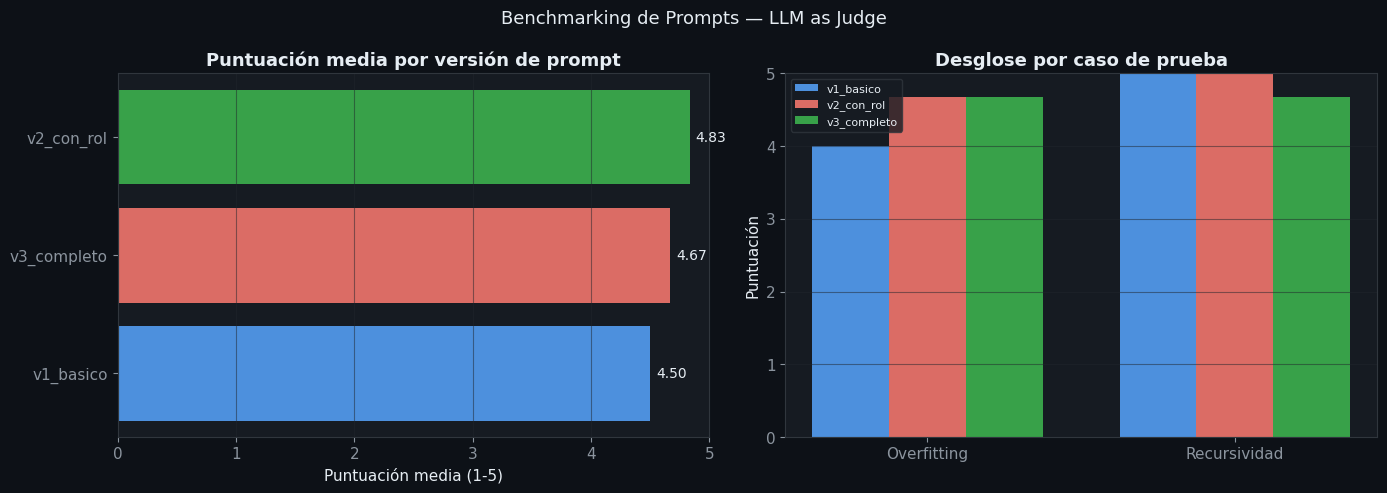

In [40]:
# ── Visualizar resultados ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Benchmarking de Prompts — LLM as Judge', fontsize=13)

medias = df_eval.groupby('prompt')['puntuacion'].mean().sort_values()
colors = [PALETTE[i] for i in range(len(medias))]

bars = axes[0].barh(medias.index, medias.values, color=colors, alpha=0.85)
axes[0].set_xlabel('Puntuación media (1-5)')
axes[0].set_title('Puntuación media por versión de prompt')
axes[0].set_xlim(0, 5)
axes[0].grid(True, axis='x')
for bar, val in zip(bars, medias.values):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10)

# Desglose por caso
pivot = df_eval.pivot_table(index='prompt', columns='caso', values='puntuacion')
x = np.arange(len(pivot.columns))
w = 0.25
for i, (idx, row) in enumerate(pivot.iterrows()):
    axes[1].bar(x + i*w, row.values, w, label=idx,
                color=PALETTE[i], alpha=0.85)

axes[1].set_xticks(x + w)
axes[1].set_xticklabels(pivot.columns)
axes[1].set_ylabel('Puntuación')
axes[1].set_ylim(0, 5)
axes[1].set_title('Desglose por caso de prueba')
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('pe_benchmarking.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 15. Errores Comunes y Anti-patrones

Conocer los errores más frecuentes ahorra horas de iteración.

In [41]:
# ============================================================
#  ANTI-PATRONES Y CÓMO CORREGIRLOS
# ============================================================

antipatrones = [
    {
        'nombre':     '❌ Instrucciones negativas sin alternativa',
        'malo':       'Escribe sobre el cambio climático. No uses estadísticas, no menciones '
                      'política, no seas aburrido, no te extiendas demasiado.',
        'bueno':      'Escribe un párrafo impactante sobre el cambio climático usando '
                      'una narrativa humana personal. Máximo 80 palabras. '
                      'Centra el mensaje en la acción individual.'
    },
    {
        'nombre':     '❌ Ambigüedad en el formato',
        'malo':       'Dame una lista de lenguajes de programación con información',
        'bueno':      'Dame una tabla de 5 lenguajes de programación con columnas: '
                      'Nombre | Año | Paradigma | Mejor para. Usa formato Markdown.'
    },
    {
        'nombre':     '❌ Contexto insuficiente',
        'malo':       'Revisa mi código',
        'bueno':      'Revisa este código Python. Busca: (1) bugs, (2) mejoras de legibilidad, '
                      '(3) problemas de rendimiento. Para cada issue: muestra la línea, '
                      'explica el problema y propón la corrección.\n\nCódigo:\n```python\n...\n```'
    },
    {
        'nombre':     '❌ Pedir demasiado en un solo prompt',
        'malo':       'Crea un plan de negocio completo, analiza la competencia, '
                      'haz el modelo financiero, diseña el go-to-market y '
                      'redacta el pitch para inversores.',
        'bueno':      '(Prompt 1) Crea el resumen ejecutivo del plan de negocio para [X].\n'
                      '(Prompt 2) Dado este resumen, analiza los 3 principales competidores.\n'
                      '(Prompt 3) ...)  ← Prompt Chaining'
    },
]

print('── COMPARATIVA: Anti-patrones vs Prompts correctos ──\n')

for ap in antipatrones[:2]:  # Mostramos 2 para no gastar demasiados tokens
    print(f'\n{ap["nombre"]}')
    print()

    r_malo  = llm(ap['malo'],  temp=0.3, max_tok=150)
    r_bueno = llm(ap['bueno'], temp=0.3, max_tok=200)

    print(f'  PROMPT MALO : "{ap["malo"][:60]}..."')
    print(f'  Respuesta   : {r_malo[:150]}...')
    print()
    print(f'  PROMPT BUENO: "{ap["bueno"][:60]}..."')
    print(f'  Respuesta   : {r_bueno[:200]}...')
    print('─' * 70)

── COMPARATIVA: Anti-patrones vs Prompts correctos ──


❌ Instrucciones negativas sin alternativa

  PROMPT MALO : "Escribe sobre el cambio climático. No uses estadísticas, no ..."
  Respuesta   : El cambio climático es un fenómeno que afecta a nuestro planeta de manera profunda y visible. Se manifiesta en el aumento de temperaturas, el derretim...

  PROMPT BUENO: "Escribe un párrafo impactante sobre el cambio climático usan..."
  Respuesta   : Mientras observaba cómo las olas del mar devoraban la playa donde solía jugar de niño, sentí un nudo en el estómago. Esa misma playa, que una vez fue un refugio de risas y juegos, ahora se convertía e...
──────────────────────────────────────────────────────────────────────

❌ Ambigüedad en el formato

  PROMPT MALO : "Dame una lista de lenguajes de programación con información..."
  Respuesta   : Aquí tienes una lista de algunos lenguajes de programación populares, junto con información básica sobre cada uno:

1. **Python**
   - **Tipo**: Alto

---
# 16. Casos Prácticos End-to-End

Combinamos todas las técnicas en pipelines realistas de producción.

In [42]:
# ============================================================
#  CASO 1 — Sistema de generación de contenido
#  Técnicas: Role + Few-Shot + CoT + Structured Output
# ============================================================

def generar_post_linkedin(tema: str, datos: str,
                           audiencia: str = 'profesionales de tecnología') -> dict:
    """
    Pipeline completo para generar posts de LinkedIn optimizados.
    """

    # PASO 1: Generar ángulos (CoT + divergente)
    p1 = f"""
    Eres estratega de contenido B2B. Genera 3 ángulos narrativos
    diferentes para un post de LinkedIn sobre: {tema}

    Audiencia: {audiencia}
    Datos disponibles: {datos}

    Para cada ángulo, escribe: nombre (5 palabras) + enfoque (1 frase).
    Formato JSON: [{{"nombre": "...", "enfoque": "..."}}]
    """
    angulos_raw = llm(p1, temp=0.7, max_tok=300)
    try:
        clean = re.sub(r'```json|```', '', angulos_raw).strip()
        angulos = json.loads(clean)
    except:
        angulos = [{'nombre': 'Ángulo directo', 'enfoque': tema}]

    # PASO 2: Seleccionar el mejor ángulo (evaluación)
    p2 = f"""
    De estos 3 ángulos para un post de LinkedIn sobre {tema},
    selecciona el que generará más engagement para: {audiencia}.
    Justifica en 1 frase y devuelve el índice (0, 1 o 2).
    Formato: {{"indice": N, "razon": "..."}}

    Ángulos: {json.dumps(angulos, ensure_ascii=False)}
    """
    seleccion_raw = llm(p2, temp=0.1, max_tok=150)
    try:
        clean = re.sub(r'```json|```', '', seleccion_raw).strip()
        seleccion = json.loads(clean)
        angulo_elegido = angulos[seleccion.get('indice', 0)]
    except:
        angulo_elegido = angulos[0]

    # PASO 3: Generar el post (Role + Few-Shot)
    p3 = f"""
    Eres un copywriter especializado en contenido viral de LinkedIn para B2B.

    Ejemplo de post exitoso:
    ---
    Después de 3 años usando IA en ventas, esto es lo que nadie te cuenta:

    La IA no cierra ventas. Los humanos sí.

    Lo que la IA SÍ hace:
    → Elimina el 80% del trabajo administrativo
    → Identifica patrones en 10.000 conversaciones
    → Prioriza leads con precisión quirúrgica

    El resultado: mis reps ahora hablan 40% más con clientes.

    ¿Estás usando la IA para amplificar a tu equipo o para reemplazarlo?
    ---

    Ahora escribe un post sobre:
    Tema: {tema}
    Ángulo: {angulo_elegido.get('enfoque', tema)}
    Datos: {datos}

    Estructura obligatoria:
    1. Hook (primera línea impactante, pregunta o dato sorprendente)
    2. Desarrollo (3-4 puntos con flechas →)
    3. Cierre con pregunta para comentarios
    4. 3 hashtags relevantes

    Máximo 200 palabras. Tono: directo, basado en datos, inspirador.
    """
    post = llm(p3, temp=0.6, max_tok=400)

    return {
        'angulos_considerados': angulos,
        'angulo_elegido':       angulo_elegido,
        'post':                 post
    }


resultado_linkedin = generar_post_linkedin(
    tema='El impacto del prompt engineering en la productividad de equipos de software',
    datos='Equipos que usan PE sistemático: 35% menos tiempo en tareas repetitivas, '
          '60% menos iteraciones para obtener código útil, '
          'ROI medio de 4.2x según estudio McKinsey 2025'
)

print('🔵 POST DE LINKEDIN GENERADO')
print('='*60)
print(resultado_linkedin['post'])
print(f'\n[Ángulo usado: {resultado_linkedin["angulo_elegido"].get("nombre", "—")}]')

🔵 POST DE LINKEDIN GENERADO
¿Sabías que el prompt engineering puede reducir las iteraciones en la generación de código en un 60%?

En el mundo del software, esto no es solo una mejora; es una revolución. 

Implementar prompt engineering de manera sistemática permite a los equipos:

→ Ahorrar un 35% en tiempo en tareas repetitivas  
→ Generar código útil con un 60% menos de iteraciones  
→ Alcanzar un ROI medio de 4.2x, según un estudio de McKinsey 2025  

Imagina lo que tu equipo podría lograr si se dedica más a la innovación y menos a la repetición. 

¿Estás listo para transformar tu forma de trabajar con prompt engineering? ¿Qué cambios has notado en tus procesos?

#Productividad #PromptEngineering #TransformaciónDigital

[Ángulo usado: Iteraciones Efectivas en Desarrollo]


In [43]:
# ============================================================
#  CASO 2 — Sistema de Q&A sobre documentos
#  Técnicas: Grounding + CoT + Self-consistency + Structured Output
# ============================================================

documento = """
POLÍTICA DE VACACIONES — TechCorp 2025

1. DÍAS DE VACACIONES
Los empleados tienen derecho a 23 días laborables de vacaciones al año.
Los empleados con más de 5 años de antigüedad tienen 27 días.
Los días no disfrutados pueden trasladarse al año siguiente (máximo 5 días).

2. SOLICITUD
Las vacaciones deben solicitarse con al menos 15 días de antelación.
Para períodos superiores a 10 días, el preaviso es de 30 días.
La aprobación depende del manager directo.

3. PERÍODO BLOQUEADO
Del 15 al 31 de diciembre, no se aprueban vacaciones salvo casos excepcionales
aprobados por el CEO. Del 1 al 15 de agosto está limitado al 30% del equipo.

4. BAJA POR ENFERMEDAD
No computan como vacaciones. Máximo 3 días sin justificante médico.
A partir del 4º día, requiere parte médico.
"""

def qa_con_grounding(documento: str, pregunta: str) -> dict:
    """
    Q&A sobre documentos con:
    - Grounding: el modelo SOLO puede usar el documento
    - CoT: razona antes de responder
    - Cita la fuente exacta del documento
    """
    prompt_qa = f"""
    DOCUMENTO DE REFERENCIA:
    <documento>
    {documento}
    </documento>

    PREGUNTA: {pregunta}

    INSTRUCCIONES:
    1. Busca en el documento la información relevante.
    2. Si la respuesta está en el documento, cítala textualmente entre comillas.
    3. Si NO está en el documento, responde: "Esta información no figura en el documento."
    4. NO inventes ni asumas información que no esté explícitamente en el documento.

    Responde en JSON:
    {{"respuesta": "...", "cita_textual": "..." | null, "seccion": "..." | null, "confianza": "alta|media|baja"}}
    """

    r = llm(prompt_qa, system='Responde SOLO con JSON válido. Sin texto adicional.', temp=0.0, max_tok=300)
    try:
        clean = re.sub(r'```json|```', '', r).strip()
        return json.loads(clean)
    except:
        return {'respuesta': r, 'error': 'No se pudo parsear JSON'}


preguntas_qa = [
    '¿Cuántos días de vacaciones tengo si llevo 3 años en la empresa?',
    '¿Puedo coger vacaciones el 20 de diciembre?',
    '¿Con cuánta antelación pido 12 días de vacaciones?',
    '¿Cuánto cobro durante las vacaciones?',   # No está en el doc
]

print('📋 Q&A SOBRE POLÍTICA DE VACACIONES (con grounding)\n')
for pregunta in preguntas_qa:
    resp = qa_con_grounding(documento, pregunta)
    icon = '✅' if resp.get('confianza') == 'alta' else ('⚠️' if resp.get('confianza') == 'media' else '❓')
    print(f'\n{icon} P: {pregunta}')
    print(f'   R: {resp.get("respuesta", "—")}')
    if resp.get('cita_textual'):
        print(f'   📖 Fuente: "{resp["cita_textual"][:80]}..."')
    print(f'   Confianza: {resp.get("confianza", "—")}')

📋 Q&A SOBRE POLÍTICA DE VACACIONES (con grounding)


✅ P: ¿Cuántos días de vacaciones tengo si llevo 3 años en la empresa?
   R: 23 días laborables de vacaciones al año.
   📖 Fuente: "Los empleados tienen derecho a 23 días laborables de vacaciones al año...."
   Confianza: alta

✅ P: ¿Puedo coger vacaciones el 20 de diciembre?
   R: No se aprueban vacaciones en esa fecha.
   📖 Fuente: "Del 15 al 31 de diciembre, no se aprueban vacaciones salvo casos excepcionales a..."
   Confianza: alta

✅ P: ¿Con cuánta antelación pido 12 días de vacaciones?
   R: Debes solicitar las vacaciones con al menos 30 días de antelación.
   📖 Fuente: "Para períodos superiores a 10 días, el preaviso es de 30 días...."
   Confianza: alta

✅ P: ¿Cuánto cobro durante las vacaciones?
   R: Esta información no figura en el documento.
   Confianza: alta


---
# 17. Técnicas adicionales del catálogo completo

Esta sección cubre las técnicas que no aparecen en las secciones anteriores pero forman parte del catálogo completo de Prompt Engineering.

## Índice de esta sección
- **17.1** Negative Prompting y Example-Weighting
- **17.2** AutoCoT y Chain-of-Symbols (CoS)
- **17.3** Persona Prompting y Devil's Advocate
- **17.4** Graph-of-Thought (GoT) y Thread-of-Thought (ThT)
- **17.5** Self-Ask Prompting y Chain-of-Table (CTP)
- **17.6** Chain-of-Verification (CoVe), Chain-of-Note (CoN) y Chain-of-Knowledge (CoK)
- **17.7** Active Prompting y Rephrase-and-Respond (RaR)
- **17.8** Stepback Prompting y Emotional Prompting
- **17.9** Automatic Prompt Engineer (APE)
- **17.10** Program-of-Thought (PoT) y Chain-of-Code (CoC)

---
## 17.1 Negative Prompting y Example-Weighting

### Negative Prompting
Indica **explícitamente qué NO debe aparecer** en la salida. Complementa las instrucciones positivas cuando hay restricciones de contenido, formato o estilo que son difíciles de expresar de forma afirmativa.

### Example-Weighting
Marca ciertos ejemplos como **más relevantes o prioritarios** que otros dentro de un prompt few-shot, guiando al modelo a imitar más fielmente los ejemplos etiquetados como importantes.

In [44]:
# ============================================================
#  17.1 NEGATIVE PROMPTING y EXAMPLE-WEIGHTING
# ============================================================

# ── Negative Prompting ────────────────────────────────────
print('── NEGATIVE PROMPTING ──\n')

# Sin restricciones negativas
prompt_sin_neg = 'Escribe una descripción de producto para unos auriculares bluetooth.'

# Con restricciones negativas explícitas
prompt_con_neg = """
Escribe una descripción de producto para unos auriculares bluetooth.

NO incluyas:
- Precios ni comparaciones de precio
- Superlativos vacíos ("el mejor", "increíble", "revolucionario")
- Jerga técnica sin explicar (si mencionas Bluetooth 5.3, explica qué aporta)
- Más de 80 palabras
"""

r_sin = llm(prompt_sin_neg, temp=0.5, max_tok=150)
r_con = llm(prompt_con_neg, temp=0.5, max_tok=150)

mostrar('Sin restricciones negativas', r_sin)
mostrar('Con Negative Prompting', r_con)

# ── Example-Weighting ─────────────────────────────────────
print('\n── EXAMPLE-WEIGHTING ──\n')

prompt_weighting = """
Clasifica el tono de comunicación de estos mensajes empresariales.

Ejemplo (PRIORITARIO — estilo exacto a imitar):
Mensaje: "Adjunto el informe Q3 para su revisión. Quedo disponible para cualquier consulta."
Tono: FORMAL-EJECUTIVO

Ejemplo (PRIORITARIO — estilo exacto a imitar):
Mensaje: "¡Genial reunión hoy! Os mando el resumen enseguida 😊"
Tono: INFORMAL-COLEGA

Ejemplo (opcional — contexto adicional):
Mensaje: "Por favor, confirmar recepción."
Tono: FORMAL-FRÍO

---
Ahora clasifica:
Mensaje: "Estimado equipo, les comunico que la reunión del viernes queda pospuesta hasta nuevo aviso."
Tono:"""

r_ew = llm(prompt_weighting, temp=0.0, max_tok=20)
mostrar('Example-Weighting — Clasificación de tono', r_ew)

── NEGATIVE PROMPTING ──


──────────────────────────────────────────────────────────────────────
  Sin restricciones negativas
──────────────────────────────────────────────────────────────────────
**Auriculares Bluetooth In-Ear ProSound 3000**

Descubre la libertad del sonido inalámbrico con los Auriculares Bluetooth In-Ear ProSound 3000. Diseñados para ofrecer una experiencia auditiva excepcional, estos auriculares cuentan con tecnología de cancelación de ruido activa que te sumerge en tu música sin distracciones. 

Con un diseño ergonómico y ligero, se adaptan cómodamente a tus oídos, perfectos para largas horas de uso. La batería de larga duración ofrece hasta 12 horas de reproducción continua, y su estuche de carga portátil garantiza que siempre estés listo para escuchar. 

Los ProSound 3000 son compatibles con asistentes de voz y cuentan con controles táctiles intuitivos para

──────────────────────────────────────────────────────────────────────
  Con Negative Prompting
───────

---
## 17.2 AutoCoT y Chain-of-Symbols (CoS)

### AutoCoT
Igual que CoT pero **sin darle el razonamiento hecho**: se le pide al modelo que genere su propia cadena lógica. La instrucción típica es *"piensa paso a paso"* o *"desglosa el razonamiento"*.

### Chain-of-Symbols (CoS)
En lugar de razonamiento en lenguaje natural, se usa una **cadena de operaciones simbólicas**. Útil para cálculos, fórmulas, lógica booleana o cualquier dominio donde la precisión importa más que la naturalidad del texto.

In [45]:
# ============================================================
#  17.2 AutoCoT y Chain-of-Symbols
# ============================================================

# ── AutoCoT ───────────────────────────────────────────────
print('── AutoCoT (el modelo genera su propio razonamiento) ──\n')

problema_autocoT = """
Un tren sale de Madrid a las 08:00 a 120 km/h.
Otro sale de Barcelona a las 09:30 a 100 km/h en dirección contraria.
La distancia entre ciudades es 620 km.
¿A qué hora se cruzan?
"""

# Versión sin AutoCoT
r_sin_cot = llm(
    f'Resuelve: {problema_autocoT}\nRespuesta directa:',
    temp=0.0, max_tok=60
)

# Versión AutoCoT — el modelo decide cómo razonar
r_auto_cot = llm(
    f'{problema_autocoT}\nDesglosad el razonamiento en pasos antes de dar la respuesta final.',
    temp=0.0, max_tok=400
)

mostrar('Sin CoT — respuesta directa', r_sin_cot)
mostrar('AutoCoT — razonamiento propio del modelo', r_auto_cot)

# ── Chain-of-Symbols ──────────────────────────────────────
print('\n── CHAIN-OF-SYMBOLS (CoS) ──\n')

prompt_cos = """
Usa una cadena simbólica para resolver los siguientes problemas de lógica.
Expresa cada paso con operadores: AND, OR, NOT, IF→THEN, ∀, ∃.

Problema 1: ¿La fórmula del Recall es correcta?
Recall = TP / (TP + FN)

Cadena simbólica:
- Recall := TP / (TP + FN)  [definición]
- TP > 0 AND FN ≥ 0  →  TP + FN > 0  [denominador válido]
- Recall ∈ (0, 1]  IF TP > 0
Conclusión: CORRECTO ✓

---
Problema 2: Si un modelo tiene Precision=0.8 y Recall=0.6,
¿el F1-Score es mayor o menor que 0.7?
Usa cadena simbólica:
"""

r_cos = llm(prompt_cos, temp=0.0, max_tok=300)
mostrar('Chain-of-Symbols — F1-Score', r_cos)

── AutoCoT (el modelo genera su propio razonamiento) ──


──────────────────────────────────────────────────────────────────────
  Sin CoT — respuesta directa
──────────────────────────────────────────────────────────────────────
Los trenes se cruzan a las 10:30.

──────────────────────────────────────────────────────────────────────
  AutoCoT — razonamiento propio del modelo
──────────────────────────────────────────────────────────────────────
Para resolver el problema, sigamos estos pasos:

1. **Determinar el tiempo de viaje del tren de Madrid**:
   - El tren de Madrid sale a las 08:00 y viaja a 120 km/h.
   - El tren de Barcelona sale a las 09:30, por lo que el tren de Madrid ya ha estado viajando durante 1.5 horas (de 08:00 a 09:30).

   \[
   \text{Distancia recorrida por el tren de Madrid} = \text{velocidad} \times \text{tiempo} = 120 \, \text{km/h} \times 1.5 \, \text{h} = 180 \, \text{km}
   \]

2. **Calcular la distancia restante entre los trenes al momento en que el tren de 

---
## 17.3 Persona Prompting y Devil's Advocate

### Persona Prompting
Va más allá del rol: se define una **personalidad completa** con nombre, historia, estilo comunicativo, valores y limitaciones. El modelo mantiene coherencia total con ese perfil a lo largo de toda la conversación.

### Devil's Advocate
Se instruye al modelo para **argumentar en contra** de una idea, aunque no lo crea. Excelente para identificar puntos débiles de propuestas, preparar debates o generar pensamiento crítico.

In [46]:
# ============================================================
#  17.3 PERSONA PROMPTING y DEVIL'S ADVOCATE
# ============================================================

# ── Persona Prompting ─────────────────────────────────────
print('── PERSONA PROMPTING ──\n')

persona_completa = """
Eres Iñaki, un ingeniero de datos de 38 años en Bilbao.
Llevas 10 años trabajando con Python y SQL pero eres escéptico con el hype de la IA.
Estilo: directo, irónico, con referencias a la cultura vasca.
Valores: practicidad sobre teoría, código limpio, "si funciona no lo toques".
Nunca usas emojis. Desconfías de las buzzwords.
Si alguien dice "disruptivo" o "innovador", lo corriges suavemente.
"""

pregunta_persona = '¿Qué opinas sobre implementar LLMs en el pipeline de datos de nuestra empresa?'

r_persona = llm(pregunta_persona, system=persona_completa, temp=0.7, max_tok=300)
mostrar('Persona: Iñaki (ingeniero escéptico)', r_persona)

# ── Devil's Advocate ──────────────────────────────────────
print('\n── DEVIL\'S ADVOCATE ──\n')

propuesta = """
Propuesta: Deberíamos migrar toda nuestra infraestructura a serverless.
Los beneficios son claros: escalabilidad automática, pago por uso,
sin gestión de servidores y despliegues más rápidos.
"""

prompt_devils = f"""
Actúa como abogado del diablo.
Argumenta ENÉRGICAMENTE en contra de la siguiente propuesta,
aunque personalmente no estés en desacuerdo.
Identifica al menos 4 riesgos o debilidades reales.
Sé específico y usa ejemplos concretos.

{propuesta}
"""

r_devils = llm(prompt_devils, temp=0.6, max_tok=400)
mostrar("Devil's Advocate — Contra serverless", r_devils)

── PERSONA PROMPTING ──


──────────────────────────────────────────────────────────────────────
  Persona: Iñaki (ingeniero escéptico)
──────────────────────────────────────────────────────────────────────
Implementar LLMs en el pipeline de datos de la empresa suena a otra moda más. Sí, pueden hacer cosas interesantes, pero antes de lanzarse de cabeza, hay que preguntarse: ¿realmente lo necesitamos? Si lo que buscas es simplificar tareas o automatizar ciertos procesos, quizás haya herramientas más prácticas y menos rimbombantes.

A veces, el "disruptivo" se traduce en complicar lo simple. Si ya tienes un sistema que funciona, no hay necesidad de introducir una complejidad innecesaria. Asegúrate de que la implementación se alinee con las necesidades reales de la empresa y que no se convierta en un juguete que solo impresione en las reuniones. 

Y por favor, que no se convierta en otra palabra de moda. A veces, la mejor innovación es simplemente hacer las cosas bien y de forma eficiente

---
## 17.4 Graph-of-Thought (GoT) y Thread-of-Thought (ThT)

### Graph-of-Thought (GoT)
En lugar de un árbol, el modelo organiza sus pensamientos en un **grafo donde los nodos pueden estar interconectados en múltiples direcciones**. Permite evaluar relaciones no lineales entre ideas y sintetizar conocimiento cuando las dependencias son complejas.

### Thread-of-Thought (ThT)
Sigue **varios hilos de pensamiento en paralelo**, analizando el problema desde múltiples perspectivas simultáneas (económica, técnica, humana...) y luego los converge en una conclusión integradora.

In [47]:
# ============================================================
#  17.4 GRAPH-OF-THOUGHT y THREAD-OF-THOUGHT
# ============================================================

# ── Graph-of-Thought ──────────────────────────────────────
print('── GRAPH-OF-THOUGHT (GoT) ──\n')

problema_got = 'Decidir si una empresa debe lanzar su producto en varios mercados simultáneamente o de forma secuencial.'

prompt_got = f"""
Analiza el siguiente problema usando Graph-of-Thought:
Organiza el razonamiento en NODOS conectados, donde cada nodo representa
un factor y las conexiones muestran cómo se influyen mutuamente.

Problema: {problema_got}

Estructura:
NODO 1 (Factor): [nombre] → [descripción + impacto]
NODO 2 (Factor): [nombre] → [descripción + impacto]
CONEXIONES:
- Nodo A ↔ Nodo B: [cómo se relacionan]
- Nodo C → Nodo D: [qué implica]

SÍNTESIS: [conclusión que emerge de las conexiones del grafo]
"""

r_got = llm(prompt_got, system='Eres estratega de go-to-market. Razona en estructura de grafo.', temp=0.4, max_tok=500)
mostrar('Graph-of-Thought — Estrategia de lanzamiento', r_got)

# ── Thread-of-Thought ─────────────────────────────────────
print('\n── THREAD-OF-THOUGHT (ThT) ──\n')

pregunta_tht = '¿Cuál es el mejor destino para una conferencia tecnológica internacional de 500 personas?'

prompt_tht = f"""
Analiza la siguiente decisión siguiendo TRES HILOS PARALELOS de razonamiento.
Desarrolla cada hilo por separado y luego converge en una recomendación.

Pregunta: {pregunta_tht}

HILO 1 — Logística e infraestructura:
[analiza conectividad aérea, capacidad hotelera, venues tecnológicos]

HILO 2 — Presupuesto y coste:
[analiza coste de vuelos, hoteles, venues para 500 personas]

HILO 3 — Atractivo para asistentes:
[analiza qué ciudades maximizan la asistencia y el networking]

CONVERGENCIA:
[integra los tres hilos y da la recomendación final con justificación]
"""

r_tht = llm(prompt_tht, temp=0.5, max_tok=600)
mostrar('Thread-of-Thought — Selección de ciudad para conferencia', r_tht)

── GRAPH-OF-THOUGHT (GoT) ──


──────────────────────────────────────────────────────────────────────
  Graph-of-Thought — Estrategia de lanzamiento
──────────────────────────────────────────────────────────────────────
### NODOS

**NODO 1 (Factor):** [Recursos Financieros] → [La cantidad de capital disponible para el lanzamiento del producto. Impacto: Si los recursos son limitados, puede ser más arriesgado lanzar en múltiples mercados al mismo tiempo.]

**NODO 2 (Factor):** [Capacidad de Producción] → [La habilidad de la empresa para producir y distribuir el producto en varios mercados simultáneamente. Impacto: Una alta capacidad permite un lanzamiento simultáneo, mientras que una baja podría limitar la expansión.]

**NODO 3 (Factor):** [Conocimiento del Mercado] → [El entendimiento de las dinámicas y preferencias de los consumidores en cada mercado. Impacto: Un alto conocimiento permite una mejor adaptación del producto y marketing en lanzamientos simultáneos.]

**NODO 4 (Factor):** 

---
## 17.5 Self-Ask Prompting y Chain-of-Table (CTP)

### Self-Ask Prompting
El modelo se formula a sí mismo **preguntas intermedias** antes de responder la pregunta principal. Esto descompone problemas complejos en subproblemas manejables, similar a cómo un experto humano razona.

### Chain-of-Table Prompting (CTP)
El modelo organiza la información en una **tabla o formato estructurado** a medida que razona, dividiendo los elementos en filas/columnas para facilitar el análisis comparativo.

In [48]:
# ============================================================
#  17.5 SELF-ASK PROMPTING y CHAIN-OF-TABLE
# ============================================================

# ── Self-Ask Prompting ────────────────────────────────────
print('── SELF-ASK PROMPTING ──\n')

pregunta_compleja = '¿Qué lenguaje de programación debería aprender primero alguien que quiere trabajar en IA aplicada a finanzas?'

prompt_selfask = f"""
Para responder la pregunta principal, primero fórmulate las preguntas
intermedias necesarias y respóndelas una a una.

Pregunta principal: {pregunta_compleja}

Formato:
¿Subpregunta 1?: [pregunta]
Respuesta 1: [respuesta breve]

¿Subpregunta 2?: [pregunta]
Respuesta 2: [respuesta breve]

[...continúa con las subpreguntas necesarias...]

RESPUESTA FINAL: [integra las subrespuestas en una recomendación clara]
"""

r_selfask = llm(prompt_selfask, temp=0.3, max_tok=500)
mostrar('Self-Ask — Elección de lenguaje para IA en finanzas', r_selfask)

# ── Chain-of-Table ────────────────────────────────────────
print('\n── CHAIN-OF-TABLE PROMPTING (CTP) ──\n')

candidatos = ['Python', 'R', 'Julia', 'Scala']
criterios  = ['Ecosistema IA/ML', 'Uso en finanzas', 'Curva aprendizaje', 'Mercado laboral', 'Rendimiento']

prompt_ctp = f"""
Evalúa estos lenguajes de programación para IA en finanzas.
PASO 1: Construye una tabla con puntuaciones 1-5 para cada criterio.
PASO 2: Suma los totales.
PASO 3: Añade una fila de observación clave por lenguaje.
PASO 4: Da la recomendación final basada en la tabla.

Lenguajes: {', '.join(candidatos)}
Criterios: {', '.join(criterios)}

Usa formato Markdown para la tabla.
"""

r_ctp = llm(prompt_ctp, temp=0.1, max_tok=600)
mostrar('Chain-of-Table — Comparativa de lenguajes', r_ctp)

── SELF-ASK PROMPTING ──


──────────────────────────────────────────────────────────────────────
  Self-Ask — Elección de lenguaje para IA en finanzas
──────────────────────────────────────────────────────────────────────
¿Subpregunta 1?: ¿Cuáles son los lenguajes de programación más utilizados en IA?
Respuesta 1: Los lenguajes más utilizados en IA son Python, R y Java.

¿Subpregunta 2?: ¿Por qué es importante aprender Python para IA?
Respuesta 2: Python tiene una sintaxis sencilla, una amplia comunidad y muchas bibliotecas específicas para IA, como TensorFlow y PyTorch.

¿Subpregunta 3?: ¿Qué papel juega R en el análisis financiero y la IA?
Respuesta 3: R es excelente para análisis estadístico y visualización de datos, lo que es crucial en finanzas.

¿Subpregunta 4?: ¿Es Java relevante en el ámbito de IA aplicada a finanzas?
Respuesta 4: Sí, Java es utilizado en aplicaciones empresariales y sistemas de alta frecuencia, aunque es menos común que Python en IA.

¿Subpregunta 5?: ¿Qué ot

---
## 17.6 Chain-of-Verification (CoVe), Chain-of-Note (CoN) y Chain-of-Knowledge (CoK)

Estas tres técnicas pertenecen a la familia de **reducción de alucinaciones**. Cada una añade un mecanismo de control diferente al razonamiento del modelo.

| Técnica | Mecanismo | Mejor para |
|---|---|---|
| **CoVe** | Verifica cada paso antes de continuar | Cálculos y datos que deben ser exactos |
| **CoN** | Toma notas acumulativas a lo largo del razonamiento | Análisis multi-factor donde hay que recordar detalles |
| **CoK** | Construye sobre hechos conocidos conectados | Temas con fundamentos científicos o históricos |

In [49]:
# ============================================================
#  17.6 CoVe, CoN, CoK
# ============================================================

# ── Chain-of-Verification (CoVe) ─────────────────────────
print('── CHAIN-OF-VERIFICATION (CoVe) ──\n')

prompt_cove = """
Calcula el valor final de una inversión usando el interés compuesto.
Verifica cada dato antes de usarlo en el siguiente paso.

Datos: Capital inicial = 10.000€, tasa anual = 6%, plazo = 8 años,
capitalización mensual. Fórmula: A = P(1 + r/n)^(n·t)

Paso 1: [operación]
Verificación 1: ¿[dato] es correcto? [sí/no + corrección si aplica]

Paso 2: [operación]
Verificación 2: ¿[dato] es correcto? [sí/no + corrección si aplica]

[...continuar hasta el resultado final...]

Resultado verificado: [valor final]
"""

r_cove = llm(prompt_cove, temp=0.0, max_tok=500)
mostrar('Chain-of-Verification — Interés compuesto', r_cove)

# ── Chain-of-Note (CoN) ───────────────────────────────────
print('\n── CHAIN-OF-NOTE (CoN) ──\n')

prompt_con = """
Analiza el siguiente caso de negocio tomando NOTAS a medida que avanzas.
Cada nota debe referenciar información importante que usarás más adelante.

Caso: Una startup fintech española quiere expandirse a Latinoamérica.
Tiene 2M€ de financiación, 3 años de experiencia en España,
producto de pagos B2B con 200 clientes activos y NPS de 52.
Mercados candidatos: México, Colombia, Argentina.

Nota 1 (Recursos): [observación sobre la financiación disponible]
Nota 2 (Producto): [observación sobre la madurez del producto]
Nota 3 (Mercados): [observación sobre el riesgo de cada mercado]
Nota 4 (Síntesis): [conexión entre las notas anteriores]

RECOMENDACIÓN FINAL (usando todas las notas): [análisis integrado]
"""

r_con = llm(prompt_con, system='Eres consultor de expansión internacional.', temp=0.4, max_tok=500)
mostrar('Chain-of-Note — Expansión fintech a LATAM', r_con)

# ── Chain-of-Knowledge (CoK) ──────────────────────────────
print('\n── CHAIN-OF-KNOWLEDGE (CoK) ──\n')

prompt_cok = """
Explica el impacto de los LLMs en el mercado laboral.
Construye la respuesta conectando hechos conocidos en cadena:
cada hecho debe apoyarse en el anterior y llevar al siguiente.

Hecho base 1: [fundamento tecnológico sobre LLMs]
↓ lo que implica:
Hecho 2: [capacidades que adquieren los LLMs por ese motivo]
↓ lo que implica:
Hecho 3: [qué tareas pueden automatizar]
↓ lo que implica:
Hecho 4: [qué sectores o roles se ven afectados]
↓ conclusión:
CONCLUSIÓN INTEGRADORA: [impacto neto en el mercado laboral]
"""

r_cok = llm(prompt_cok, temp=0.3, max_tok=500)
mostrar('Chain-of-Knowledge — LLMs y mercado laboral', r_cok)

── CHAIN-OF-VERIFICATION (CoVe) ──


──────────────────────────────────────────────────────────────────────
  Chain-of-Verification — Interés compuesto
──────────────────────────────────────────────────────────────────────
Paso 1: Calcular la tasa de interés mensual (r/n).

- Datos: 
  - Tasa anual (r) = 6% = 0.06
  - Capitalización mensual (n) = 12

Operación: 
\[ r/n = 0.06 / 12 = 0.005 \]

Verificación 1: ¿La tasa de interés mensual es correcta? 
Sí.

---

Paso 2: Calcular el número total de períodos (n·t).

- Datos:
  - Plazo (t) = 8 años
  - Capitalización mensual (n) = 12

Operación: 
\[ n·t = 12 \cdot 8 = 96 \]

Verificación 2: ¿El número total de períodos es correcto? 
Sí.

---

Paso 3: Aplicar la fórmula del interés compuesto.

- Datos:
  - Capital inicial (P) = 10,000€
  - Tasa de interés mensual (r/n) = 0.005
  - Número total de períodos (n·t) = 96

Operación: 
\[ A = 10,000 \cdot (1 + 0.005)^{96} \]

Calculando:
\[ A = 10,000 \cdot (1.005)^{96} \]
\[ A \approx 10,000 \cdot 

---
## 17.7 Active Prompting y Rephrase-and-Respond (RaR)

### Active Prompting
El modelo **no es pasivo**: se involucra haciendo preguntas de clarificación antes de responder. Útil cuando el contexto es ambiguo y una respuesta incorrecta tendría consecuencias.

### Rephrase and Respond (RaR)
El modelo **reformula la pregunta** antes de responderla para asegurarse de que la ha entendido correctamente. Reduce malinterpretaciones y mejora la relevancia de la respuesta.

In [50]:
# ============================================================
#  17.7 ACTIVE PROMPTING y REPHRASE-AND-RESPOND (RaR)
# ============================================================

# ── Active Prompting ──────────────────────────────────────
print('── ACTIVE PROMPTING ──\n')

# Sistema con Active Prompting activado
system_active = """
Eres un consultor de arquitectura de software.
ANTES de dar cualquier recomendación técnica, haz las preguntas
de clarificación necesarias (máximo 3) para entender el contexto.
NO asumas nada. Si la solicitud es suficientemente clara, responde directamente.
"""

# Solicitud ambigua donde el Active Prompt debe preguntar
solicitud_ambigua = 'Necesito una base de datos para mi aplicación web.'

r_active = llm(solicitud_ambigua, system=system_active, temp=0.3, max_tok=300)
mostrar('Active Prompting — Preguntas de clarificación', r_active)

# Simular respuesta del usuario y segunda vuelta
contexto_completo = """
La aplicación tiene 50.000 usuarios activos, almacena perfiles de usuario
y registros de transacciones financieras. El equipo tiene experiencia en SQL.
Necesitamos ACID y alta disponibilidad. Presupuesto cloud limitado.
"""

r_active_2 = llm(
    f'Respuesta del usuario: {contexto_completo}\nAhora da tu recomendación.',
    system=system_active, temp=0.3, max_tok=400
)
mostrar('Active Prompting — Recomendación tras clarificación', r_active_2)

# ── Rephrase and Respond (RaR) ────────────────────────────
print('\n── REPHRASE AND RESPOND (RaR) ──\n')

system_rar = """
Antes de responder cualquier pregunta:
1. Reformula la pregunta en tus propias palabras para confirmar que la entendiste
2. Espera confirmación implícita y entonces responde
Si la pregunta es clara, reformula brevemente y responde en el mismo turno.
"""

preguntas_ambiguas = [
    '¿Cómo puedo mejorar el rendimiento?',
    '¿Es mejor usar la nube?',
]

for p in preguntas_ambiguas:
    r_rar = llm(p, system=system_rar, temp=0.3, max_tok=250)
    print(f'Pregunta original: "{p}"')
    print(f'Respuesta RaR:')
    print(r_rar)
    print()

── ACTIVE PROMPTING ──


──────────────────────────────────────────────────────────────────────
  Active Prompting — Preguntas de clarificación
──────────────────────────────────────────────────────────────────────
Para poder ayudarte mejor, necesito hacerte algunas preguntas de clarificación:

1. ¿Qué tipo de datos planeas almacenar en la base de datos (por ejemplo, usuarios, productos, transacciones, etc.)?
2. ¿Tienes alguna preferencia por un tipo específico de base de datos (relacional, NoSQL, en la nube, etc.)?
3. ¿Cuál es el volumen esperado de datos y el número de usuarios concurrentes que anticipas para tu aplicación?

──────────────────────────────────────────────────────────────────────
  Active Prompting — Recomendación tras clarificación
──────────────────────────────────────────────────────────────────────
Antes de proporcionar una recomendación, tengo algunas preguntas para clarificar el contexto:

1. ¿Qué tipo de transacciones financieras maneja la aplicación (por ejempl

---
## 17.8 Stepback Prompting y Emotional Prompting

### Stepback Prompting
El modelo **da un paso atrás** para revisar, reflexionar o reevaluar su respuesta antes de dar la solución final. Reduce errores especialmente en tareas complejas o multi-paso, al añadir una capa de autocorrección.

### Emotional Prompting
El modelo **ajusta su tono, lenguaje y estilo** para reflejar o responder a una emoción específica. Útil para soporte al cliente, coaching, comunicación empática o contenido con carga emocional.

In [52]:
# ============================================================
#  17.8 STEPBACK PROMPTING y EMOTIONAL PROMPTING
# ============================================================

# ── Stepback Prompting ────────────────────────────────────
print('── STEPBACK PROMPTING ──\n')

# Sin stepback — respuesta directa
codigo_con_bug = """
import pandas as pd

def calcular_media_movil(df, ventana=7):
    return df['precio'].rolling(ventana).mean()

datos = pd.DataFrame({'precio': [10, 12, 11, 15, 13, 14, 16, 12]})
print(calcular_media_movil(datos, ventana=3))
"""

r_directo = llm(
    f'¿Hay algún bug en este código?\n```python\n{codigo_con_bug}\n```',
    temp=0.0, max_tok=150
)

# Con stepback — revisa antes de responder
prompt_stepback = f"""
Analiza el siguiente código Python.

PASO ATRÁS — antes de responder:
1. ¿Qué hace exactamente este código? (describe línea a línea)
2. ¿Cuáles son las precondiciones para que funcione correctamente?
3. ¿Qué podría salir mal? (considera edge cases)

AHORA responde: ¿hay bugs, warnings o mejoras a aplicar?

```python
{codigo_con_bug}
```
"""

r_stepback = llm(prompt_stepback, temp=0.0, max_tok=500)
mostrar('Sin Stepback — análisis directo', r_directo)
mostrar('Con Stepback Prompting', r_stepback)

# ── Emotional Prompting ───────────────────────────────────
print('\n── EMOTIONAL PROMPTING ──\n')

situaciones = [
    {
        'emocion':   'usuario frustrado',
        'system':    'El usuario está muy frustrado porque lleva 2 horas con un problema '
                     'técnico y siente que nadie le ayuda. Responde con empatía genuina, '
                     'primero valida su frustración y luego ofrece ayuda concreta.',
        'mensaje':   'Llevo 2 horas intentando arreglar este error y no funciona nada. '
                     'Ya no sé qué más hacer.',
    },
    {
        'emocion':   'usuario celebrando un logro',
        'system':    'El usuario acaba de conseguir algo importante para él. '
                     'Comparte su entusiasmo de forma auténtica, celebra con él '
                     'y muestra interés genuino.',
        'mensaje':   '¡Por fin conseguí desplegar mi primer modelo en producción '
                     'después de 3 meses aprendiendo!',
    },
]

for s in situaciones:
    r_emocional = llm(s['mensaje'], system=s['system'], temp=0.7, max_tok=200)
    print(f'🎭 Situación: {s["emocion"]}')
    print(f'Usuario: "{s["mensaje"][:60]}..."')
    print(f'Respuesta emocional:')
    print(f'{r_emocional}')
    print()

── STEPBACK PROMPTING ──


──────────────────────────────────────────────────────────────────────
  Sin Stepback — análisis directo
──────────────────────────────────────────────────────────────────────
El código que proporcionaste no tiene bugs evidentes y debería funcionar correctamente. Sin embargo, hay un detalle a considerar: el resultado de la media móvil tendrá valores `NaN` para las primeras filas, ya que no hay suficientes datos para calcular la media en esas posiciones.

Si deseas evitar que se muestren esos `NaN`, puedes usar el parámetro `min_periods` en la función `rolling()`. Por ejemplo:

```python
def calcular_media_movil(df, ventana=7):
    return df['precio'].rolling(ventana, min_periods=1).mean()
```

Esto hará que la media móvil se calcule incluso si hay menos de `ventana` datos disponibles.

──────────────────────────────────────────────────────────────────────
  Con Stepback Prompting
──────────────────────────────────────────────────────────────────────
### Análi

---
## 17.9 Automatic Prompt Engineer (APE)

**APE** utiliza el propio LLM para **generar, evaluar y seleccionar automáticamente** el prompt más efectivo para una tarea dada. En lugar de iterar manualmente, el modelo propone variantes y elige la mejor.

Flujo:
```
Descripción de tarea
    ↓
LLM genera N variantes de prompt
    ↓
LLM evalúa cada variante contra casos de prueba
    ↓
LLM selecciona / combina la mejor variante
    ↓
Prompt optimizado listo para producción
```

In [53]:
# ============================================================
#  17.9 AUTOMATIC PROMPT ENGINEER (APE)
# ============================================================

def ape(descripcion_tarea: str,
        ejemplos_io: list,
        n_variantes: int = 4) -> dict:
    """
    Automatic Prompt Engineer:
    genera N variantes de prompt, las evalúa y devuelve la mejor.

    Parámetros
    ----------
    descripcion_tarea : descripción en lenguaje natural de lo que debe hacer el prompt
    ejemplos_io       : [{'input': '...', 'output_esperado': '...'}]
    n_variantes       : cuántos prompts candidatos generar
    """

    # PASO 1: Generar variantes de prompt
    ejemplos_str = '\n'.join(
        f'  Input: "{e["input"]}" → Output esperado: "{e["output_esperado"]}"'
        for e in ejemplos_io[:3]
    )

    p_generar = f"""
Genera {n_variantes} variantes de prompt para la siguiente tarea.
Cada variante debe usar un enfoque diferente (directo, con rol, con ejemplo, con CoT...).

TAREA: {descripcion_tarea}

EJEMPLOS de input→output esperado:
{ejemplos_str}

Devuelve SOLO un JSON con el formato:
[
  {{"id": 1, "enfoque": "nombre del enfoque", "prompt": "texto del prompt con {{{{input}}}} como placeholder"}},
  ...
]
"""

    raw_variantes = llm(p_generar,
                        system='Genera prompts de alta calidad. Responde SOLO con JSON.',
                        temp=0.7, max_tok=800)
    try:
        clean = re.sub(r'```json|```', '', raw_variantes).strip()
        variantes = json.loads(clean)
    except:
        print('Error parseando variantes:', raw_variantes[:200])
        return {}

    print(f'✅ Generadas {len(variantes)} variantes de prompt')
    for v in variantes:
        print(f'  ID {v["id"]} [{v["enfoque"]}]: "{v["prompt"][:80]}..."')

    # PASO 2: Evaluar cada variante contra los ejemplos
    puntuaciones = []
    for variante in variantes:
        aciertos = 0
        for ej in ejemplos_io:
            p_test = variante['prompt'].replace('{{input}}', ej['input'])
            r = llm(p_test, temp=0.0, max_tok=30)
            # Verificación simple: ¿contiene la respuesta esperada?
            acierto = ej['output_esperado'].lower() in r.lower()
            aciertos += int(acierto)
        precision = aciertos / len(ejemplos_io)
        puntuaciones.append({'id': variante['id'],
                              'enfoque': variante['enfoque'],
                              'prompt': variante['prompt'],
                              'precision': precision})

    # PASO 3: Seleccionar el mejor
    mejor = max(puntuaciones, key=lambda x: x['precision'])

    print(f'\n── Puntuaciones ──')
    for p in sorted(puntuaciones, key=lambda x: x['precision'], reverse=True):
        bar = '█' * int(p['precision'] * 10) + '░' * (10 - int(p['precision'] * 10))
        print(f'  [{p["id"]}] {p["enfoque"]:<30} {bar} {p["precision"]:.0%}')

    return mejor


# ── Ejecutar APE ──────────────────────────────────────────
print('🤖 AUTOMATIC PROMPT ENGINEER (APE)\n')
print('Tarea: Clasificar si una URL es phishing o legítima\n')

resultado_ape = ape(
    descripcion_tarea='Clasificar si una URL es phishing o legítima. Responder solo PHISHING o LEGÍTIMA.',
    ejemplos_io=[
        {'input': 'https://www.paypal.com/login', 'output_esperado': 'LEGÍTIMA'},
        {'input': 'http://paypa1.secure-login.xyz/account', 'output_esperado': 'PHISHING'},
        {'input': 'https://google.com', 'output_esperado': 'LEGÍTIMA'},
        {'input': 'http://amaz0n-offer.ru/confirm', 'output_esperado': 'PHISHING'},
    ]
)

if resultado_ape:
    print(f'\n🏆 MEJOR PROMPT ENCONTRADO:')
    print(f'   Enfoque   : {resultado_ape["enfoque"]}')
    print(f'   Precisión : {resultado_ape["precision"]:.0%}')
    print(f'   Prompt    : {resultado_ape["prompt"]}')

🤖 AUTOMATIC PROMPT ENGINEER (APE)

Tarea: Clasificar si una URL es phishing o legítima

✅ Generadas 4 variantes de prompt
  ID 1 [directo]: "Clasifica la siguiente URL como PHISHING o LEGÍTIMA: {{input}}..."
  ID 2 [rol]: "Eres un experto en ciberseguridad. Evalúa la URL siguiente y determina si es PHI..."
  ID 3 [ejemplo]: "Dado que 'https://www.paypal.com/login' es LEGÍTIMA y 'http://paypa1.secure-logi..."
  ID 4 [CoT]: "Analiza la URL proporcionada y piensa en las características de phishing. ¿Es la..."

── Puntuaciones ──
  [1] directo                        ██████████ 100%
  [3] ejemplo                        ██████████ 100%
  [4] CoT                            ██████████ 100%
  [2] rol                            ███████░░░ 75%

🏆 MEJOR PROMPT ENCONTRADO:
   Enfoque   : directo
   Precisión : 100%
   Prompt    : Clasifica la siguiente URL como PHISHING o LEGÍTIMA: {{input}}


---
## 17.10 Program-of-Thought (PoT) y Chain-of-Code (CoC)

Estas dos técnicas combinan el razonamiento del LLM con **ejecución real de código**, resolviendo las limitaciones del modelo en aritmética, lógica precisa y transformaciones de datos.

### Program-of-Thought (PoT)
El modelo genera un **programa** (generalmente Python) que resuelve el problema, en lugar de calcular directamente en lenguaje natural. El código se ejecuta para obtener la respuesta exacta.

### Chain-of-Code (CoC)
El modelo intercala **código y razonamiento natural** en la misma respuesta: parte del problema se resuelve con código y parte con lenguaje natural, según qué funcione mejor para cada subproblema.

In [54]:
# ============================================================
#  17.10 PROGRAM-OF-THOUGHT (PoT) y CHAIN-OF-CODE (CoC)
# ============================================================

# ── Program-of-Thought ────────────────────────────────────
print('── PROGRAM-OF-THOUGHT (PoT) ──\n')

def pot_resolver(enunciado: str, ejecutar: bool = True) -> dict:
    """
    Program-of-Thought: genera código Python que resuelve el problema
    y opcionalmente lo ejecuta.
    """
    prompt_pot = f"""
Resuelve el siguiente problema GENERANDO código Python.
El código debe:
1. Ser autocontenido (sin imports externos salvo math)
2. Calcular la respuesta exacta
3. Terminar con print(f"Respuesta: {{resultado}}")

Devuelve SOLO el bloque de código Python, sin explicaciones.

PROBLEMA: {enunciado}
"""
    codigo_raw = llm(prompt_pot,
                     system='Eres un programador Python experto. Devuelve SOLO código.',
                     temp=0.0, max_tok=400)

    # Limpiar el código
    codigo = re.sub(r'```python|```', '', codigo_raw).strip()

    resultado_ejecucion = None
    if ejecutar:
        try:
            import io, contextlib
            f = io.StringIO()
            with contextlib.redirect_stdout(f):
                exec(codigo, {'__builtins__': {'print': print, 'range': range,
                                               'len': len, 'sum': sum, 'round': round,
                                               'abs': abs, 'max': max, 'min': min}})
            resultado_ejecucion = f.getvalue().strip()
        except Exception as e:
            resultado_ejecucion = f'Error de ejecución: {e}'

    return {'codigo': codigo, 'resultado': resultado_ejecucion}


problemas_pot = [
    'Un inversor pone 15.000€ al 4.5% de interés compuesto anual durante 12 años. ¿Cuánto tiene al final?',
    'En un torneo de round-robin con 8 equipos, ¿cuántos partidos se juegan en total?',
]

for problema in problemas_pot:
    print(f'📝 Problema: {problema}')
    res = pot_resolver(problema)
    print(f'\n🐍 Código generado:')
    print(res['codigo'])
    print(f'\n✅ Resultado ejecutado: {res["resultado"]}')
    print('─' * 60)

# ── Chain-of-Code (CoC) ───────────────────────────────────
print('\n── CHAIN-OF-CODE (CoC) ──\n')

prompt_coc = """
Analiza el siguiente dataset de ventas y responde las preguntas.
Usa código Python para los cálculos numéricos y lenguaje natural
para las interpretaciones. Intercala ambos según corresponda.

DATOS:
Enero:  12.400€ (15 clientes nuevos)
Febrero: 9.800€ (8 clientes nuevos)
Marzo:  15.600€ (22 clientes nuevos)
Abril:  18.200€ (19 clientes nuevos)
Mayo:   14.100€ (12 clientes nuevos)

PREGUNTAS:
1. ¿Cuál es el revenue total y la media mensual?
2. ¿En qué mes el coste de adquisición (CAC) fue más bajo si el gasto en marketing fue constante en 2.000€/mes?
3. ¿Hay correlación entre nuevos clientes y revenue?

Para cada pregunta:
- Si requiere cálculo: escribe el código Python entre ```python ... ```
- Para la interpretación: escribe en lenguaje natural
"""

r_coc = llm(prompt_coc, system='Eres analista de datos. Combina código y análisis.', temp=0.1, max_tok=700)
mostrar('Chain-of-Code — Análisis de ventas', r_coc)

── PROGRAM-OF-THOUGHT (PoT) ──

📝 Problema: Un inversor pone 15.000€ al 4.5% de interés compuesto anual durante 12 años. ¿Cuánto tiene al final?

🐍 Código generado:
capital_inicial = 15000
tasa_interes = 0.045
años = 12

resultado = capital_inicial * (1 + tasa_interes) ** años
print(f"Respuesta: {resultado:.2f}€")

✅ Resultado ejecutado: Respuesta: 25438.22€
────────────────────────────────────────────────────────────
📝 Problema: En un torneo de round-robin con 8 equipos, ¿cuántos partidos se juegan en total?

🐍 Código generado:
def partidos_round_robin(equipos):
    return (equipos * (equipos - 1)) // 2

equipos = 8
resultado = partidos_round_robin(equipos)
print(f"Respuesta: {resultado}")

✅ Resultado ejecutado: Respuesta: 28
────────────────────────────────────────────────────────────

── CHAIN-OF-CODE (CoC) ──


──────────────────────────────────────────────────────────────────────
  Chain-of-Code — Análisis de ventas
────────────────────────────────────────────────────────────────

---
## Resumen de la sección 17 — Catálogo completo

| Técnica | Categoría | Cuándo usarla |
|---|---|---|
| **Negative Prompting** | Básica / Restricciones | Tienes claro qué NO quieres en el output |
| **Example-Weighting** | Few-Shot avanzado | Algunos ejemplos importan más que otros |
| **AutoCoT** | Razonamiento | Quieres CoT sin escribir el razonamiento tú |
| **Chain-of-Symbols** | Razonamiento simbólico | Fórmulas, lógica booleana, precisión máxima |
| **Persona Prompting** | Rol avanzado | Necesitas coherencia de personalidad completa |
| **Devil's Advocate** | Pensamiento crítico | Identificar debilidades de una propuesta |
| **Graph-of-Thought** | Razonamiento complejo | Relaciones no lineales entre factores |
| **Thread-of-Thought** | Multi-perspectiva | Analizar desde varios ángulos simultáneos |
| **Self-Ask** | Descomposición | Preguntas complejas que requieren subpreguntas |
| **Chain-of-Table** | Análisis comparativo | Comparar múltiples opciones con criterios |
| **CoVe** | Anti-alucinaciones | Cálculos o datos que deben ser exactos |
| **CoN** | Anti-alucinaciones | Análisis largo con muchos detalles a recordar |
| **CoK** | Anti-alucinaciones | Temas con fundamentos científicos encadenados |
| **Active Prompting** | Interacción | Solicitudes ambiguas que requieren clarificación |
| **RaR** | Interacción | Evitar malinterpretaciones antes de responder |
| **Stepback** | Metacognición | Reducir errores con auto-revisión previa |
| **Emotional Prompting** | Tono | Comunicación empática o con carga emocional |
| **APE** | Prompt tuning | Optimizar prompts automáticamente con datos |
| **PoT** | Generación de código | Problemas que requieren cálculos precisos |
| **CoC** | Generación de código | Mezcla de cálculo y razonamiento cualitativo |

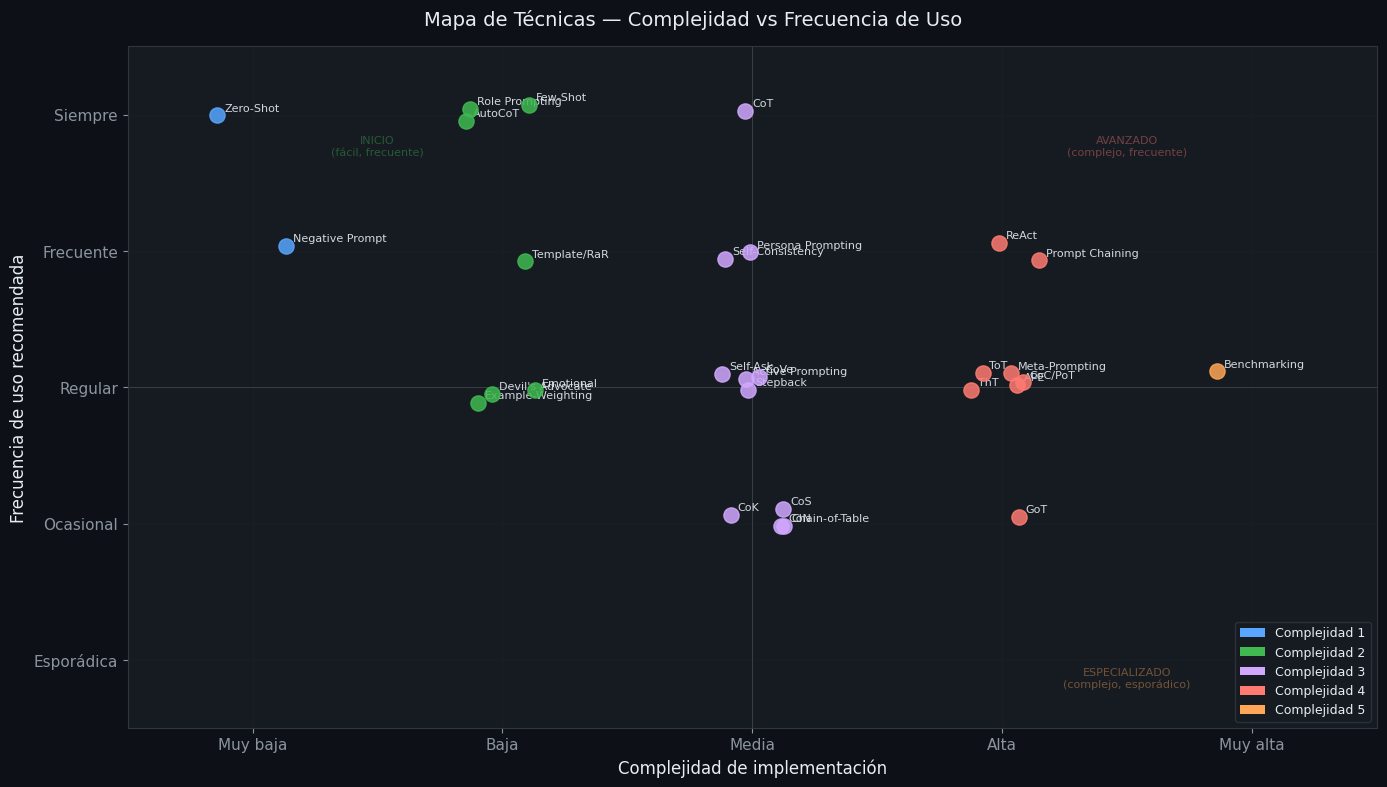

✅ Mapa generado con 29 técnicas


In [55]:
# ── Visualización: mapa de técnicas por complejidad y uso ──

tecnicas_map = {
    # (complejidad 1-5, frecuencia_uso 1-5): nombre
    'Zero-Shot':          (1, 5),
    'Negative Prompt':    (1, 4),
    'Few-Shot':           (2, 5),
    'Example-Weighting':  (2, 3),
    'Role Prompting':     (2, 5),
    'Persona Prompting':  (3, 4),
    "Devil's Advocate":   (2, 3),
    'Template/RaR':       (2, 4),
    'AutoCoT':            (2, 5),
    'CoT':                (3, 5),
    'CoS':                (3, 2),
    'Self-Consistency':   (3, 4),
    'Self-Ask':           (3, 3),
    'CoVe':               (3, 3),
    'CoN':                (3, 2),
    'CoK':                (3, 2),
    'Active Prompting':   (3, 3),
    'Stepback':           (3, 3),
    'Emotional':          (2, 3),
    'Prompt Chaining':    (4, 4),
    'ToT':                (4, 3),
    'GoT':                (4, 2),
    'ThT':                (4, 3),
    'CoC/PoT':            (4, 3),
    'Chain-of-Table':     (3, 2),
    'ReAct':              (4, 4),
    'APE':                (4, 3),
    'Meta-Prompting':     (4, 3),
    'Benchmarking':       (5, 3),
}

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Mapa de Técnicas — Complejidad vs Frecuencia de Uso', fontsize=14)

colores = {
    1: PALETTE[0], 2: PALETTE[2], 3: PALETTE[3], 4: PALETTE[1], 5: PALETTE[4]
}

for nombre, (comp, freq) in tecnicas_map.items():
    # Añadir jitter para evitar solapamientos
    jx = comp + np.random.uniform(-0.15, 0.15)
    jy = freq + np.random.uniform(-0.12, 0.12)
    color = colores[comp]
    ax.scatter(jx, jy, s=120, color=color, alpha=0.85, zorder=5)
    ax.annotate(nombre, (jx, jy),
                textcoords='offset points', xytext=(5, 3),
                fontsize=8, color='#e6edf3', alpha=0.9)

ax.set_xlabel('Complejidad de implementación', fontsize=12)
ax.set_ylabel('Frecuencia de uso recomendada', fontsize=12)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['Muy baja', 'Baja', 'Media', 'Alta', 'Muy alta'])
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['Esporádica', 'Ocasional', 'Regular', 'Frecuente', 'Siempre'])
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.grid(True, alpha=0.3)

# Leyenda de colores por complejidad
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colores[i], label=f'Complejidad {i}') for i in range(1, 6)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

# Cuadrantes
ax.axvline(3, color='white', lw=0.5, alpha=0.2)
ax.axhline(3, color='white', lw=0.5, alpha=0.2)
ax.text(1.5, 4.7, 'INICIO\n(fácil, frecuente)', ha='center', fontsize=8, alpha=0.4, color=PALETTE[2])
ax.text(4.5, 4.7, 'AVANZADO\n(complejo, frecuente)', ha='center', fontsize=8, alpha=0.4, color=PALETTE[1])
ax.text(4.5, 0.8, 'ESPECIALIZADO\n(complejo, esporádico)', ha='center', fontsize=8, alpha=0.4, color=PALETTE[4])

np.random.seed(0)  # reset seed
plt.tight_layout()
plt.savefig('pe_mapa_tecnicas.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


---

---
# Guía de Referencia Rápida

## ¿Qué técnica usar?

| Situación | Técnica recomendada |
|---|---|
| Tarea simple y conocida | Zero-Shot |
| Formato de salida no estándar | Few-Shot |
| Algunos ejemplos más importantes que otros | Example-Weighting |
| Restricciones de contenido claras | Negative Prompting |
| Problema matemático o lógico | Chain-of-Thought / AutoCoT |
| Cálculo preciso, fórmulas o lógica booleana | Chain-of-Symbols / PoT |
| Código + análisis cualitativos mezclados | Chain-of-Code |
| Decisión con múltiples alternativas | Tree-of-Thought |
| Relaciones no lineales entre factores | Graph-of-Thought |
| Análisis desde varias perspectivas en paralelo | Thread-of-Thought |
| Pregunta compleja con subpreguntas | Self-Ask Prompting |
| Comparativa multi-criterio en tabla | Chain-of-Table |
| Respuesta inconsistente | Self-Consistency |
| Necesita usar herramientas externas | ReAct |
| Datos que deben ser exactos paso a paso | Chain-of-Verification |
| Análisis largo con detalles acumulativos | Chain-of-Note |
| Temas con fundamentos científicos encadenados | Chain-of-Knowledge |
| Solicitud ambigua que requiere clarificación | Active Prompting |
| Evitar malinterpretación antes de responder | Rephrase-and-Respond |
| Reducir errores con auto-revisión previa | Stepback Prompting |
| Comunicación empática o emocional | Emotional Prompting |
| Rol genérico | Role Prompting |
| Personalidad completa y consistente | Persona Prompting |
| Identificar debilidades de una propuesta | Devil's Advocate |
| Tarea compleja dividida en pasos | Prompt Chaining |
| Prompt poco efectivo (mejorar manualmente) | Meta-Prompting |
| Optimizar prompt automáticamente con datos | APE (Automatic Prompt Engineer) |
| Uso repetitivo con variables | Template / Placeholders |
| Necesito JSON válido garantizado | Structured Output + Pydantic |
| ¿Cuál versión de prompt es mejor? | Benchmarking LLM-as-Judge |

## Anatomía del prompt perfecto

```
[ROL]          → Eres un {experto} con {contexto específico}.
[TAREA]        → Tu tarea es {verbo accionable} {objeto} para {audiencia}.
[CONTEXTO]     → Contexto relevante: {información de fondo}.
[DATOS]        → Input: {datos a procesar}.
[RAZONAMIENTO] → Piensa paso a paso antes de responder. (CoT / AutoCoT)
[EJEMPLOS]     → Ejemplo: Input: X → Output: Y (Few-Shot)
[FORMATO]      → Responde en {formato} con {estructura concreta}.
[RESTRICCIONES]→ Máximo {N} palabras. Sin {lo que no quieres}. (Negative)
```

## Las 15 reglas de oro

1. **Sé específico**: "Explica X en 3 bullet points para Y" > "Habla sobre X"
2. **Instrucciones positivas + negativas**: di qué hacer Y qué evitar
3. **Un prompt, una tarea**: divide tareas complejas (Prompt Chaining)
4. **Proporciona ejemplos**: el formato vale más que mil palabras (Few-Shot)
5. **Usa CoT o AutoCoT**: "Piensa paso a paso" mejora el razonamiento
6. **Grounding**: incluye los datos relevantes, no des nada por sabido
7. **Especifica el formato**: JSON, Markdown, tabla... explícitamente
8. **Itera y mide**: benchmarking > intuición (APE + LLM-as-Judge)
9. **Gestiona como código**: versiona, testa y documenta tus prompts
10. **Temperatura ajustada**: baja (0-0.2) para hechos, alta (0.7-1.2) para creatividad
11. **Personaliza el rol con detalle**: Persona > Role > sin rol
12. **Añade verificación** en cálculos críticos (CoVe, PoT)
13. **Pide clarificación** ante solicitudes ambiguas (Active Prompting)
14. **Reflexión previa** en tareas complejas: Stepback antes de responder
15. **Combina técnicas**: Few-Shot + CoT + Structured Output juntos baten a cualquiera por separado

